# V-JEPA 2 and 2.1 Feature Analysis for Surgical Tracking

## Models We Use & Why

| Model | Architecture | Dimensions | Source | Purpose |
|-------|-------------|------------|--------|---------|
| **V-JEPA 2 Large** | ViT-L/16 | 1024-d, 24 layers | HuggingFace `facebook/vjepa2-vitl-fpc64-256` + custom checkpoint | Best accuracy, trained on human videos |
| **V-JEPA 2.1 Base** | ViT-B/16 | 768-d, 12 layers | torch.hub `facebookresearch/vjepa2` | Faster inference, newer architecture |
| **DINOv2 Base** | ViT-B/14 | 768-d, 12 layers | torch.hub `facebookresearch/dinov2` | Spatial-only baseline, image features |
| **DINOv2 Small+Reg** | ViT-S/14 + 4 registers | 384-d, 12 layers | Local checkpoint `dinov2_vits14_reg4_pretrain.pth` | Lightweight, registers reduce artifacts |
| **TIPSv2 SO400m/14** | ViT-SO400m/14 | 1152-d, 27 layers | HuggingFace `google/tipsv2-so400m14` | Vision-language, patch-text alignment, zero-shot |

### Input Format Differences (CRITICAL)
- **V-JEPA 2** (HuggingFace): `(B, T, C, H, W)` - temporal dimension before channels
- **V-JEPA 2.1** (torch.hub): `(B, C, T, H, W)` - channels before temporal (standard video format)
- **DINOv2**: `(B, C, H, W)` - single image, no temporal dimension
- **TIPSv2**: `(B, C, H, W)` - single image, values in [0,1] (no ImageNet norm), resize to 448x448

### System Checkpoint Structure
`latest-supervised.pth.tar` contains:
- `encoder`: 158 params - V-JEPA 2.1 ViT-B backbone
- `predictor`: NOT PRESENT (None) - the checkpoint doesn't include predictor weights
- `detr_head`: 100 params - Surgical tool detection head
- `reid_head`: 4 params - Person re-identification head

**Goal**: Extract encoder+predictor only, exclude DETR/ReID heads for pure feature extraction.

### Critical Implementation Notes
1. V-JEPA 2.1 from torch.hub returns `(model, transform)` tuple - must unpack
2. DINOv2 requires input size divisible by patch size (14): 392x392 for 384 input
3. TIPSv2 uses `trust_remote_code=True` and `model.encode_image()` API, no ImageNet normalization
4. Use `torch.autocast(DEVICE, dtype=DTYPE)` for all inference to avoid dtype mismatches
5. `strict=False` required when loading custom checkpoints into HuggingFace models

**Run cells in order! Cell 2 must execute before Cell 3.**

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.decomposition import PCA
import torch.nn.functional as F
import sys
import math
from typing import Dict, List, Optional

# --- Constants ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
IMG_SIZE = 384
DINOV2_PATCH = 14
DINOV2_SIZE = ((IMG_SIZE + DINOV2_PATCH - 1) // DINOV2_PATCH) * DINOV2_PATCH  # 392

# Model Paths
VJ_2_CHECKPOINT = Path(r"I:\surgi_world_track\vjepa_encoder_human.pt")
VJ_2_HF_NAME = "facebook/vjepa2-vitl-fpc64-256"
SYSTEM_CHECKPOINT = Path(r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar")
VIDEO_DIR = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")

print(f"Device: {DEVICE}  |  Dtype: {DTYPE}")

Device: cuda  |  Dtype: torch.bfloat16


In [2]:
# --- Load All Models and Video ---
# This cell must run BEFORE the layer-wise analysis cell
import torchvision.transforms as transforms

def load_frame_sequence(path, start_frame=0, num_frames=16):
    """Load a sequence of frames from a directory."""
    frames_paths = sorted(list(Path(path).glob("*.png"))) + sorted(list(Path(path).glob("*.jpg")))
    if len(frames_paths) == 0:
        return None, []
    
    selected_paths = frames_paths[start_frame : start_frame + num_frames]
    frames = []
    original_images = []
    for f in selected_paths:
        img = Image.open(f).convert('RGB')
        original_images.append(np.array(img))
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        frames.append(transforms.ToTensor()(img_resized))
    
    # Stack to (T, C, H, W) -> (1, C, T, H, W)
    video = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0)
    return video.to(DEVICE).to(DTYPE), original_images

def load_video_segment(path, start_frame=0, num_frames=16):
    """Fallback if cv2 is available for video files, otherwise uses load_frame_sequence logic."""
    return load_frame_sequence(path, start_frame, num_frames)

def load_video_or_frames(input_path, start_frame=0, num_frames=16):
    input_path = Path(input_path)
    if input_path.is_dir():
        return load_frame_sequence(input_path, start_frame, num_frames)
    return None, []

# Load video
print("Loading video segment...")
video_input, original_frames = load_video_or_frames(VIDEO_DIR, start_frame=0, num_frames=16)
if video_input is not None:
    print(f"✓ Video loaded: {video_input.shape}")
else:
    print("⚠ Could not load video, using dummy tensor")
    video_input = torch.randn(1, 3, 16, IMG_SIZE, IMG_SIZE).to(DEVICE).to(DTYPE)
    original_frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * 16

# Load V-JEPA 2.1 Base for layer analysis
print("\nLoading V-JEPA 2.1 Base (768 dim)...")
vjepa21_result = torch.hub.load('facebookresearch/vjepa2:main', 'vjepa2_1_vit_base_384', trust_repo=True)

# Handle tuple return (model, transform) or dict
if isinstance(vjepa21_result, tuple):
    vjepa21_base = vjepa21_result[0]
elif isinstance(vjepa21_result, dict):
    vjepa21_base = vjepa21_result.get('model', vjepa21_result.get('encoder', list(vjepa21_result.values())[0]))
else:
    vjepa21_base = vjepa21_result

vjepa21_base = vjepa21_base.to(DEVICE).to(DTYPE).eval()
print(f"✓ V-JEPA 2.1 Base loaded: {sum(p.numel() for p in vjepa21_base.parameters()):,} params")

print("\n[READY] Models and video loaded. Run next cell for layer-wise PCA analysis.")

Loading video segment...
✓ Video loaded: torch.Size([1, 3, 16, 384, 384])

Loading V-JEPA 2.1 Base (768 dim)...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main
h:\anatomical_classification\miniconda3\envs\dino\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\anatomical_classification\miniconda3\envs\dino\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✓ V-JEPA 2.1 Base loaded: 86,833,152 params

[READY] Models and video loaded. Run next cell for layer-wise PCA analysis.


Extracting features from V-JEPA 2.1 Base layers: [3, 6, 9, 12]
Model type: VisionTransformer
  Captured layer 3: shape torch.Size([1, 8, 576, 768])
  Captured layer 6: shape torch.Size([1, 8, 576, 768])
  Captured layer 9: shape torch.Size([1, 8, 576, 768])
  Captured layer 12: shape torch.Size([1, 8, 576, 768])

✓ Extracted 4 layer features


h:\anatomical_classification\miniconda3\envs\dino\lib\contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


  Layer 3: PC1+PC2 = 37.29% variance
  Layer 6: PC1+PC2 = 34.58% variance
  Layer 9: PC1+PC2 = 33.08% variance
  Layer 12: PC1+PC2 = 33.62% variance


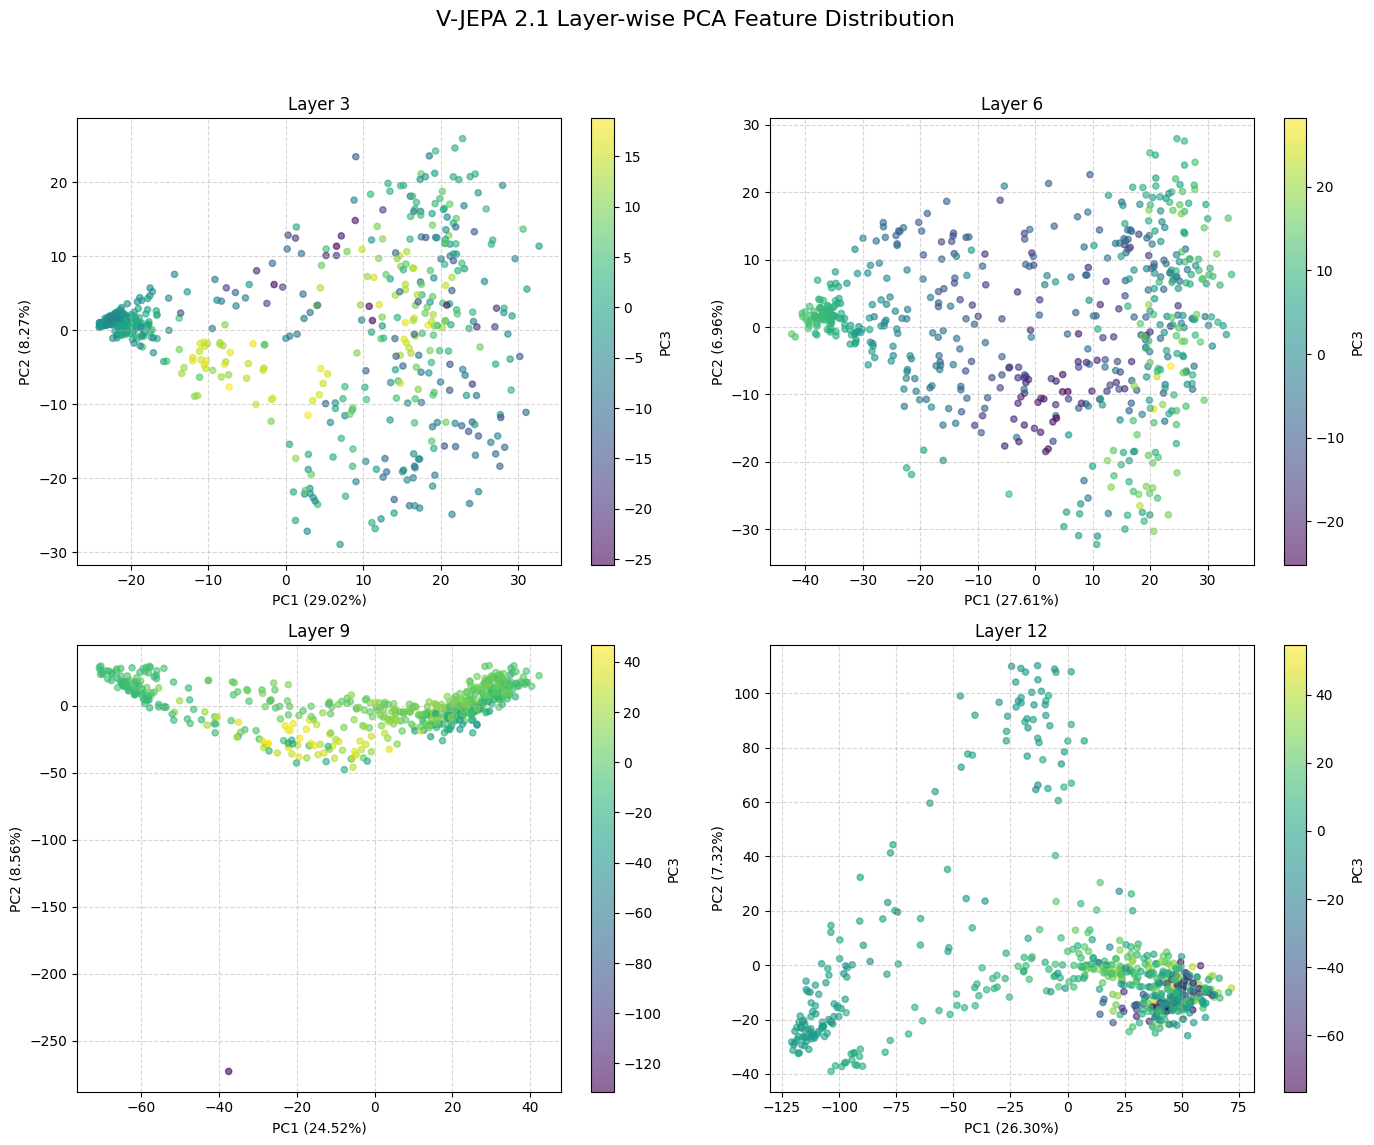

In [3]:
# --- Layer-wise Feature Extraction and PCA Analysis ---
# This cell depends on vjepa21_base and video_input from Cell 2
# MODELS: V-JEPA 2.1 Base (ViT-B/16, 768-dim) - extracting intermediate layer features

from sklearn.decomposition import PCA

# Define layer indices for V-JEPA 2.1 Base (ViT-B has 12 layers)
LAYER_INDICES = [3, 6, 9, 12]
vjepa_features = []
vjepa_pcas = []

print(f"Extracting features from V-JEPA 2.1 Base layers: {LAYER_INDICES}")
print(f"Model type: {type(vjepa21_base).__name__}")

def get_vjepa_layer_features(model, video_input, layers):
    """Extract intermediate layer features from V-JEPA 2.1.
    
    Mirrors VisionTransformer.forward() from the official source:
    1. patch_embed(x) -> (B, T_patches*H_patches*W_patches, D)
    2. Add modality embedding (video_mod_embed) if present
    3. For each block: block(x, T=T_patches, H_patches, W_patches) -> (x, attn)
       V-JEPA 2.1 uses RoPE — no additive pos_embed; position encoding is
       applied inside RoPEAttention via rotate_queries_or_keys().
    """
    features = []
    
    with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
        # V-JEPA 2.1 expects (B, C, T, H, W)
        B, C, T, H, W = video_input.shape
        
        # Compute patch dimensions (same as VisionTransformer.forward lines 268-271)
        T_patches = T // model.tubelet_size   # e.g. 16//2 = 8
        H_patches = H // model.patch_size     # e.g. 384//16 = 24
        W_patches = W // model.patch_size     # e.g. 384//16 = 24
        
        # Patch embedding: Conv3d -> (B, T_patches*H_patches*W_patches, D)
        x = model.patch_embed(video_input)
        
        # Add video modality embedding if present (VisionTransformer lines 284-288)
        if model.modality_embedding:
            x += model.video_mod_embed.repeat(x.shape[0], 1, 1)
        
        # Note: V-JEPA 2.1 uses RoPE (use_rope=True), so NO additive pos_embed.
        # Position encoding is handled inside RoPEAttention via rotate_queries_or_keys.
        
        # Pass through blocks, collecting intermediate features
        for i, block in enumerate(model.blocks):
            # Block.forward always returns (x, attn) tuple
            x, _ = block(
                x,
                T=T_patches,
                H_patches=H_patches,
                W_patches=W_patches,
            )
                
            if (i + 1) in layers:
                # Reshape: (B, T_patches*H_patches*W_patches, C) -> (B, T_patches, H_patches*W_patches, C)
                N_total = x.shape[1]
                C = x.shape[2]
                N_spatial = H_patches * W_patches
                feat = x.reshape(B, T_patches, N_spatial, C)
                features.append(feat)
                print(f"  Captured layer {i+1}: shape {feat.shape}")
    
    return features

# Extract features
vjepa_features = get_vjepa_layer_features(vjepa21_base, video_input, LAYER_INDICES)
print(f"\n✓ Extracted {len(vjepa_features)} layer features")

# Fit PCA for each layer
for i, feat in enumerate(vjepa_features):
    feat_frame = feat[0, 0].cpu().float().numpy()
    pca = PCA(n_components=3)
    pca.fit(feat_frame)
    vjepa_pcas.append(pca)
    print(f"  Layer {LAYER_INDICES[i]}: PC1+PC2 = {sum(pca.explained_variance_ratio_[:2]):.2%} variance")

def plot_pca_scatter(pcas, features_list, title="Layer-wise PCA Feature Distribution"):
    """Plot PCA scatter for each layer."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for i, (pca, feat, ax) in enumerate(zip(pcas, features_list, axes)):
        feat_frame = feat[0, 0].cpu().float().numpy()
        feat_pca = pca.transform(feat_frame)
        
        scatter = ax.scatter(feat_pca[:, 0], feat_pca[:, 1], c=feat_pca[:, 2], cmap='viridis', s=20, alpha=0.6)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        ax.set_title(f'Layer {LAYER_INDICES[i]}')
        fig.colorbar(scatter, ax=ax, label='PC3')
        ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run visualization
plot_pca_scatter(vjepa_pcas, vjepa_features, title="V-JEPA 2.1 Layer-wise PCA Feature Distribution")

In [4]:
# --- Load and Test SurgicalTrackingSystem ---
# SELF-CONTAINED: run this cell independently
# Uses extract_encoder_only=True to skip DETR/ReID heads and load only encoder+predictor

import sys
sys.path.insert(0, r'I:\surgi_world_track')

# Force reimport in case of cached module
if 'core_app.models.vjepa_world_model' in sys.modules:
    del sys.modules['core_app.models.vjepa_world_model']

try:
    from core_app.models.vjepa_world_model import load_vjepa_world_model_fixed
except ImportError:
    import importlib.util
    spec = importlib.util.spec_from_file_location("vjepa_world_model", r"I:\surgi_world_track\core_app\models\vjepa_world_model.py")
    module = importlib.util.module_from_spec(spec)
    sys.modules["vjepa_world_model"] = module
    spec.loader.exec_module(module)
    load_vjepa_world_model_fixed = module.load_vjepa_world_model_fixed
    print("Loaded function via importlib fallback")

import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from pathlib import Path
import torch

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
SYSTEM_CHECKPOINT = Path(r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar")
VIDEO_DIR = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")

def load_video_or_frames(input_path, start_frame=0, num_frames=16):
    input_path = Path(input_path)
    if not input_path.is_dir():
        return None, []
    frames_paths = sorted(list(input_path.glob("*.png"))) + sorted(list(input_path.glob("*.jpg")))
    if len(frames_paths) == 0:
        return None, []
    selected_paths = frames_paths[start_frame : start_frame + num_frames]
    frames = []
    original_images = []
    for f in selected_paths:
        img = Image.open(f).convert('RGB')
        original_images.append(np.array(img))
        img_resized = img.resize((384, 384))
        frames.append(transforms.ToTensor()(img_resized))
    video = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0)
    return video.to(DEVICE).to(DTYPE), original_images

# Load only the encoder (no DETR/ReID heads)
if SYSTEM_CHECKPOINT.exists():
    print(f"Loading encoder from {SYSTEM_CHECKPOINT.name}...")
    print("  (extract_encoder_only=True - skipping DETR and ReID heads)")
    try:
        model = load_vjepa_world_model_fixed(
            str(SYSTEM_CHECKPOINT), 
            use_vjepa21=True, 
            extract_encoder_only=True  # Only load encoder, skip tracking heads
        )
        model = model.to(DEVICE).eval()
        print(f"\n✓ Model loaded on {DEVICE}")
        encoder_dim = model.world_model.encoder_dim
        print(f"  - Encoder dim: {encoder_dim}")
        print(f"  - World model components: encoder + predictor + neck")
        print(f"  - Tracking heads: disabled (num_tools=0)")
        
        # Test inference using encoder only (feature extraction mode)
        video_tensor, original_frames = load_video_or_frames(VIDEO_DIR, start_frame=0, num_frames=16)
        if video_tensor is not None:
            print(f"\n✓ Video loaded: {video_tensor.shape}")
            
            with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
                video_input = video_tensor.to(DEVICE)
                # Use mode='inference' - DETR/ReID heads won't be called since num_tools=0
                outputs = model(video_input, mode='inference')
            
            print(f"\n✓ Inference complete!")
            print(f"  Output keys: {list(outputs.keys())}")
            if 'world_features' in outputs:
                print(f"  World features: {outputs['world_features'].shape}")
            if 'encoder_features' in outputs:
                print(f"  Encoder features: {outputs['encoder_features'].shape}")
            
            # Note: Since num_tools=0, detr_logits and reid_embeddings will be None
            print(f"\n  (Tracking outputs disabled - encoder-only mode)")
        else:
            print("❌ Video not found for inference test.")
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ System checkpoint not found: {SYSTEM_CHECKPOINT}")

Loading encoder from latest-supervised.pth.tar...
  (extract_encoder_only=True - skipping DETR and ReID heads)
Creating SurgicalTrackingSystem:
  encoder_dim=768, reid_input_dim=256
  model_name=vjepa2_1_vit_base_384, use_vjepa21=True
  extract_encoder_only=True, num_tools=0
Loading V-JEPA 2.1 from torch.hub: facebookresearch/vjepa2:vjepa2_1_vit_base_384


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


V-JEPA encoder frozen


h:\anatomical_classification\miniconda3\envs\dino\lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


  Skipping DETR and ReID head weights (extract_encoder_only=True)
Loaded checkpoint: 158 parameters
  Missing: 264 keys

✓ Model loaded on cuda
  - Encoder dim: 768
  - World model components: encoder + predictor + neck
  - Tracking heads: disabled (num_tools=0)

✓ Video loaded: torch.Size([1, 3, 16, 384, 384])


h:\anatomical_classification\miniconda3\envs\dino\lib\contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)



✓ Inference complete!
  Output keys: ['detr', 'reid', 'predictions', 'neck_out', 'reality_seq']

  (Tracking outputs disabled - encoder-only mode)


# --- Cleanup ---
The following cells contain deprecated or redundant analysis from previous debugging sessions.

In [5]:
# Simple V-JEPA Encoder Inspection
# This loads ONLY the encoder from your checkpoint, not the full tracking system

from pathlib import Path
import torch

# Load just the encoder from your checkpoint
checkpoint_path = Path(r"I:\surgi_world_track\vjepa_encoder_human.pt")
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)

print("=== Checkpoint Structure ===")
print(f"Top-level keys: {list(checkpoint.keys())}")

print("\n=== Encoder State Dict ===")
encoder_sd = checkpoint['encoder']
print(f"Number of parameters: {len(encoder_sd)}")

print("\n=== Encoder Architecture Info ===")
# Infer architecture from parameter shapes
for key in ['backbone.patch_embed.proj.weight', 'module.backbone.patch_embed.proj.weight']:
    if key in encoder_sd:
        shape = encoder_sd[key].shape
        print(f"Patch embed: {shape} -> embed_dim = {shape[0]}")
        break

# Count blocks
block_idxs = set()
for k in encoder_sd.keys():
    if 'blocks.' in k:
        import re
        match = re.search(r'blocks\.(\d+)', k)
        if match:
            block_idxs.add(int(match.group(1)))
print(f"Number of transformer blocks: {max(block_idxs) + 1 if block_idxs else 'unknown'}")

print("\n=== Sample Parameter Shapes ===")
for i, (k, v) in enumerate(list(encoder_sd.items())[:10]):
    print(f"{k}: {tuple(v.shape)}")

# Try loading with HuggingFace
print("\n=== Loading with HuggingFace VJEPA2Model ===")
try:
    from transformers import VJEPA2Model
    # Try ViT-L first (based on checkpoint inspection)
    hf_model_name = "facebook/vjepa2-vitl-fpc64-256"
    print(f"Loading {hf_model_name}...")
    encoder = VJEPA2Model.from_pretrained(hf_model_name, torch_dtype=DTYPE)
    print(f"HF model loaded: {type(encoder)}")
    print(f"Config: hidden_size={encoder.config.hidden_size}, num_hidden_layers={encoder.config.num_hidden_layers}")
    
    # Check if checkpoint matches
    print(f"\nCheckpoint embed_dim matches HF model: {encoder.config.hidden_size == 1024}")
    
    # Try loading checkpoint weights
    encoder_sd_clean = {k.replace('module.', '').replace('backbone.', ''): v for k, v in encoder_sd.items()}
    msg = encoder.load_state_dict(encoder_sd_clean, strict=False)
    print(f"Loaded checkpoint weights: {msg}")
    
    encoder = encoder.to(DEVICE).to(DTYPE).eval()
    print(f"\nEncoder ready on {DEVICE}")
    
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

=== Checkpoint Structure ===
Top-level keys: ['encoder', 'predictor', 'opt', 'scaler', 'target_encoder', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']

=== Encoder State Dict ===
Number of parameters: 292

=== Encoder Architecture Info ===
Patch embed: torch.Size([1024, 3, 2, 16, 16]) -> embed_dim = 1024
Number of transformer blocks: 24

=== Sample Parameter Shapes ===
module.backbone.patch_embed.proj.weight: (1024, 3, 2, 16, 16)
module.backbone.patch_embed.proj.bias: (1024,)
module.backbone.blocks.0.norm1.weight: (1024,)
module.backbone.blocks.0.norm1.bias: (1024,)
module.backbone.blocks.0.attn.qkv.weight: (3072, 1024)
module.backbone.blocks.0.attn.qkv.bias: (3072,)
module.backbone.blocks.0.attn.proj.weight: (1024, 1024)
module.backbone.blocks.0.attn.proj.bias: (1024,)
module.backbone.blocks.0.norm2.weight: (1024,)
module.backbone.blocks.0.norm2.bias: (1024,)

=== Loading with HuggingFace VJEPA2Model ===
Loading facebook/vjepa2-vitl-fpc64-256...


Loading weights: 100%|██████████| 587/587 [00:23<00:00, 25.11it/s] 


HF model loaded: <class 'transformers.models.vjepa2.modeling_vjepa2.VJEPA2Model'>
Config: hidden_size=1024, num_hidden_layers=24

Checkpoint embed_dim matches HF model: True
Loaded checkpoint weights: _IncompatibleKeys(missing_keys=['encoder.embeddings.patch_embeddings.proj.weight', 'encoder.embeddings.patch_embeddings.proj.bias', 'encoder.layer.0.norm1.weight', 'encoder.layer.0.norm1.bias', 'encoder.layer.0.attention.query.weight', 'encoder.layer.0.attention.query.bias', 'encoder.layer.0.attention.key.weight', 'encoder.layer.0.attention.key.bias', 'encoder.layer.0.attention.value.weight', 'encoder.layer.0.attention.value.bias', 'encoder.layer.0.attention.proj.weight', 'encoder.layer.0.attention.proj.bias', 'encoder.layer.0.norm2.weight', 'encoder.layer.0.norm2.bias', 'encoder.layer.0.mlp.fc1.weight', 'encoder.layer.0.mlp.fc1.bias', 'encoder.layer.0.mlp.fc2.weight', 'encoder.layer.0.mlp.fc2.bias', 'encoder.layer.1.norm1.weight', 'encoder.layer.1.norm1.bias', 'encoder.layer.1.attention.

Loaded video: torch.Size([1, 3, 16, 384, 384])
Last layer features shape: torch.Size([1, 4608, 1024])
Reshaping: (B=1, TN=4608, C=1024) -> (B=1, T=16, N=288, C=1024)
Final features shape: torch.Size([1, 16, 288, 1024])


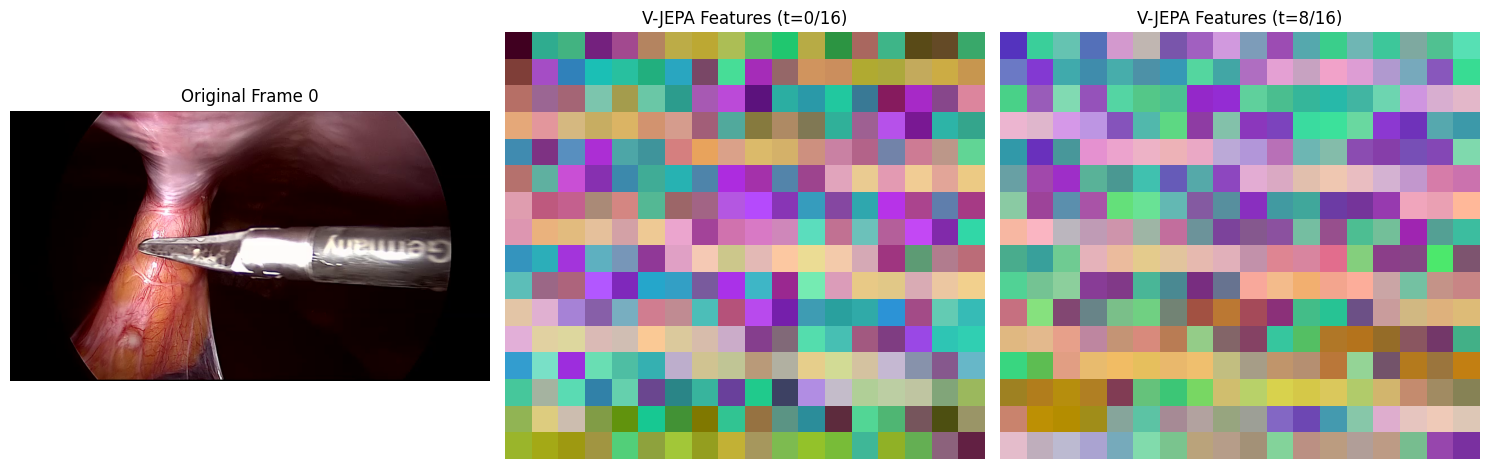


Encoder works! Output shape: torch.Size([1, 16, 288, 1024])
  B=1, T=16, N=288, C=1024


In [8]:
# Test V-JEPA Encoder on Video
# This uses the encoder loaded in Cell 6 - no tracking system needed

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load a video segment
VIDEO_PATH = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")
video_tensor, original_frames = load_video_or_frames(VIDEO_PATH, start_frame=0, num_frames=16)
print(f"Loaded video: {video_tensor.shape}")

# Extract features with the encoder (loaded in Cell 6)
# The encoder expects (B, T, C, H, W) format for HF model
video_hf = video_tensor.permute(0, 2, 1, 3, 4)  # (B, T, C, H, W)

with torch.no_grad():
    outputs = encoder(pixel_values_videos=video_hf, skip_predictor=True, output_hidden_states=True)
    
# Get features from last layer
last_layer_features = outputs.hidden_states[-1]  # (B, T, N, C) or (B, TN, C)
print(f"Last layer features shape: {last_layer_features.shape}")

# V-JEPA2 may return flattened features (B, TN, C) where T=temporal, N=spatial combined
# Let's reshape if needed
B = last_layer_features.shape[0]
if last_layer_features.dim() == 3:
    # Already flattened: (B, TN, C) - need to reshape to (B, T, N, C)
    # For 16 frames at 384x384 with 16x16 patches and tubelet size 2
    # We get T=8 temporal tokens, N=576 spatial tokens per frame
    TN, C = last_layer_features.shape[1], last_layer_features.shape[2]
    # Try to infer T - common V-JEPA configs: T=8 for tubelet=2 with 16 frames
    for T in [16, 8, 4, 2]:
        if TN % T == 0:
            N = TN // T
            print(f"Reshaping: (B={B}, TN={TN}, C={C}) -> (B={B}, T={T}, N={N}, C={C})")
            last_layer_features = last_layer_features.reshape(B, T, N, C)
            break

print(f"Final features shape: {last_layer_features.shape}")

# Visualize with PCA
def visualize_features(features, title, t_idx=0):
    """Simple PCA visualization of features at time t_idx."""
    # features: (B, T, N, C)
    feat_t = features[0, t_idx]  # (N, C)
    feat_np = feat_t.cpu().float().numpy()
    
    # PCA to 3 components
    pca = PCA(n_components=3)
    feat_pca = pca.fit_transform(feat_np)
    
    # Normalize to [0, 1]
    feat_pca = (feat_pca - feat_pca.min()) / (feat_pca.max() - feat_pca.min() + 1e-8)
    
    # Reshape to square grid
    N = feat_pca.shape[0]
    H = W = int(N ** 0.5)
    if H * W != N:
        # Find best rectangular grid
        for h in range(int(N**0.5), 0, -1):
            if N % h == 0:
                H, W = h, N // h
                break
    
    img = feat_pca.reshape(H, W, 3)
    return img

# Show original frame and feature visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_frames[0])
axes[0].set_title("Original Frame 0")
axes[0].axis('off')

T = last_layer_features.shape[1]
axes[1].imshow(visualize_features(last_layer_features, "Features t=0", t_idx=0))
axes[1].set_title(f"V-JEPA Features (t=0/{T})")
axes[1].axis('off')

mid_t = T // 2
axes[2].imshow(visualize_features(last_layer_features, f"Features t={mid_t}", t_idx=mid_t))
axes[2].set_title(f"V-JEPA Features (t={mid_t}/{T})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nEncoder works! Output shape: {last_layer_features.shape}")
print(f"  B={last_layer_features.shape[0]}, T={last_layer_features.shape[1]}, N={last_layer_features.shape[2]}, C={last_layer_features.shape[3]}")

In [ ]:
# Compare V-JEPA 2 Base, V-JEPA 2.1 Base, and DINOv2 Base on same video frame
# SELF-CONTAINED: includes video loading

import torch
from pathlib import Path
import torch.nn.functional as F
import sys
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def load_video_or_frames(input_path, start_frame=0, num_frames=16):
    input_path = Path(input_path)
    if not input_path.is_dir():
        return None, []
    frames_paths = sorted(list(input_path.glob("*.png"))) + sorted(list(input_path.glob("*.jpg")))
    if len(frames_paths) == 0:
        return None, []
    selected_paths = frames_paths[start_frame : start_frame + num_frames]
    frames = []
    original_images = []
    for f in selected_paths:
        img = Image.open(f).convert('RGB')
        original_images.append(np.array(img))
        img_resized = img.resize((384, 384))
        frames.append(transforms.ToTensor()(img_resized))
    video = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0)
    return video.to(DEVICE).to(DTYPE), original_images

# --- Load all three encoders ---

# 1. V-JEPA 2 Base
print("Loading V-JEPA 2 Base...")
from transformers import VJEPA2Model
vjepa2_base = VJEPA2Model.from_pretrained("facebook/vjepa2-vitl-fpc64-256", torch_dtype=DTYPE)
checkpoint_vjepa2 = torch.load(Path(r"I:\surgi_world_track\vjepa_encoder_human.pt"), map_location='cpu', weights_only=True)
encoder_sd = {k.replace('module.', '').replace('backbone.', ''): v for k, v in checkpoint_vjepa2['encoder'].items()}
vjepa2_base.load_state_dict(encoder_sd, strict=False)
vjepa2_base = vjepa2_base.to(DEVICE).to(DTYPE).eval()
print("  V-JEPA 2 Base: ViT-L 1024d (custom checkpoint)")

# 2. V-JEPA 2.1 Base - from torch.hub
print("\nLoading V-JEPA 2.1 Base...")
for key in list(sys.modules.keys()):
    if key == 'app' or key.startswith('app.'):
        del sys.modules[key]
hub_result = torch.hub.load('facebookresearch/vjepa2', model='vjepa2_1_vit_base_384', pretrained=False)
if isinstance(hub_result, tuple):
    vjepa21_base = hub_result[0]
else:
    vjepa21_base = hub_result
vjepa21_base = vjepa21_base.to(DEVICE).to(DTYPE).eval()
print("  V-JEPA 2.1 Base: ViT-B 768d loaded")

# 3. DINOv2 Base
print("\nLoading DINOv2 Base...")
dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', pretrained=True)
dinov2_base = dinov2_base.to(DEVICE).to(DTYPE).eval()
print("  DINOv2 Base: ViT-B 768d (patch 14) loaded")

# --- Load video ---
VIDEO_PATH = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")
video_tensor, original_frames = load_video_or_frames(VIDEO_PATH, start_frame=0, num_frames=16)
print(f"\nLoaded video: {video_tensor.shape}")

# For DINOv2: resize to 392x392 (divisible by 14)
DINO_SIZE = 392
dino_frame = F.interpolate(video_tensor[0, :, 0:1], size=(DINO_SIZE, DINO_SIZE), mode='bilinear', align_corners=False)
dino_frame = dino_frame.squeeze(1).unsqueeze(0)  # (1, C, 392, 392)

# For V-JEPA 2 (HF model): use (B, T, C, H, W) format
video_hf = video_tensor.permute(0, 2, 1, 3, 4)  # (B, T, C, H, W)

# For V-JEPA 2.1 (torch.hub model): use (B, C, T, H, W) format
video_hub = video_tensor  # Already (B, C, T, H, W)

# --- Extract features ---
features = {}

# V-JEPA 2 Base
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    out = vjepa2_base(pixel_values_videos=video_hf, skip_predictor=True, output_hidden_states=True)
    feat = out.hidden_states[-1]
    if feat.dim() == 3:
        B, TN, C = feat.shape
        T = 8
        N = TN // T
        feat = feat.reshape(B, T, N, C)
    features['V-JEPA 2 Base'] = feat
    print(f"V-JEPA 2 features: {feat.shape}")

# V-JEPA 2.1 Base - MUST use autocast to prevent dtype mismatch in SDPA
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    feat21 = vjepa21_base(video_hub)
    if isinstance(feat21, tuple):
        feat21 = feat21[0]
    if feat21.dim() == 3:
        B, TN, C = feat21.shape
        T_temp = 8
        N = TN // T_temp
        feat21 = feat21.reshape(B, T_temp, N, C)
    features['V-JEPA 2.1 Base'] = feat21
    print(f"V-JEPA 2.1 features: {feat21.shape}")

# DINOv2 Base
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    dino_out = dinov2_base.forward_features(dino_frame)
    if isinstance(dino_out, dict):
        feat_dino = dino_out['x_norm_patchtokens']
    else:
        feat_dino = dino_out
    feat_dino = feat_dino.unsqueeze(1)
    features['DINOv2 Base'] = feat_dino
    print(f"DINOv2 features: {feat_dino.shape} (frame {DINO_SIZE}x{DINO_SIZE})")

# --- Visualize ---
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

axes[0].imshow(original_frames[0])
axes[0].set_title("Original Frame (384x384)", fontsize=14)
axes[0].axis('off')

def viz_features_simple(features, t_idx=0):
    feat_t = features[0, min(t_idx, features.shape[1]-1)]
    feat_np = feat_t.cpu().float().numpy()
    pca = PCA(n_components=3)
    feat_pca = pca.fit_transform(feat_np)
    feat_pca = (feat_pca - feat_pca.min()) / (feat_pca.max() - feat_pca.min() + 1e-8)
    N = feat_pca.shape[0]
    H = W = int(N ** 0.5)
    if H * W != N:
        for h in range(int(N**0.5), 0, -1):
            if N % h == 0:
                H, W = h, N // h
                break
    return feat_pca.reshape(H, W, 3)

for idx, (name, feat) in enumerate(features.items(), 1):
    t_idx = 0 if feat.shape[1] > 1 else 0
    axes[idx].imshow(viz_features_simple(feat, t_idx))
    axes[idx].set_title(f"{name}\n{tuple(feat.shape)}, t={t_idx}", fontsize=12)
    axes[idx].axis('off')

if len(features) < 3:
    axes[3].axis('off')

plt.suptitle("Encoder Comparison: Same Input Frame", fontsize=16)
plt.tight_layout()
plt.show()

# --- Summary ---
print("\n" + "="*60)
print("ENCODER COMPARISON SUMMARY")
print("="*60)
for name, feat in features.items():
    B, T, N, C = feat.shape if feat.dim() == 4 else (feat.shape[0], 1, feat.shape[1], feat.shape[2])
    print(f"\n{name}:")
    print(f"  Shape: {tuple(feat.shape)}")
    print(f"  Temporal: {T}, Spatial tokens: {N}, Dim: {C}")
    print(f"  Grid: ~{int(N**0.5)}x{int(N**0.5)} tokens")
print("="*60)

Loading V-JEPA 2 Base...


Loading weights: 100%|██████████| 587/587 [00:00<00:00, 3652.21it/s]


  V-JEPA 2 Base: ViT-L 1024d (custom checkpoint)

Loading V-JEPA 2.1 Base...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


  V-JEPA 2.1 Base: ViT-B 768d loaded

Loading DINOv2 Base...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_dinov2_main


  DINOv2 Base: ViT-B 768d (patch 14) loaded

Loaded video: torch.Size([1, 3, 16, 384, 384])
V-JEPA 2 features: torch.Size([1, 8, 576, 1024])


h:\anatomical_classification\miniconda3\envs\dino\lib\contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


RuntimeError: Expected query, key, and value to have the same dtype, but got query.dtype: float key.dtype: float and value.dtype: struct c10::BFloat16 instead.

Loading V-JEPA 2 Large...


Loading weights: 100%|██████████| 587/587 [00:00<00:00, 4476.56it/s]


  V-JEPA 2 Large: ViT-L 1024d loaded

Loading V-JEPA 2.1 Base (pretrained)...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


  V-JEPA 2.1 Base (pretrained): ViT-B 768d loaded

Loading V-JEPA 2.1 Base (supervised, Cholec20 fine-tuned)...


...

Loading weights: 100%|██████████| 323/323 [00:00<00:00, 6935.11it/s]


  TIP-SV2 B/14: ViT-B 768d loaded

Loaded video: torch.Size([1, 3, 16, 384, 384])
V-JEPA 2 Large: torch.Size([1, 8, 576, 1024])
V-JEPA 2.1 pretrained: torch.Size([1, 8, 576, 768])
V-JEPA 2.1 supervised: torch.Size([1, 8, 576, 768])
DINOv2 Base: torch.Size([1, 1, 784, 768])
DINOv2 Small: torch.Size([1, 1, 784, 384])


h:\anatomical_classification\miniconda3\envs\dino\lib\contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


TIPSv2: torch.Size([1, 1, 1024, 1152])
TIP-SV2 B/14: torch.Size([1, 1, 1024, 768])


C:\Users\sc23pg\AppData\Local\Temp\ipykernel_17456\2620931054.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


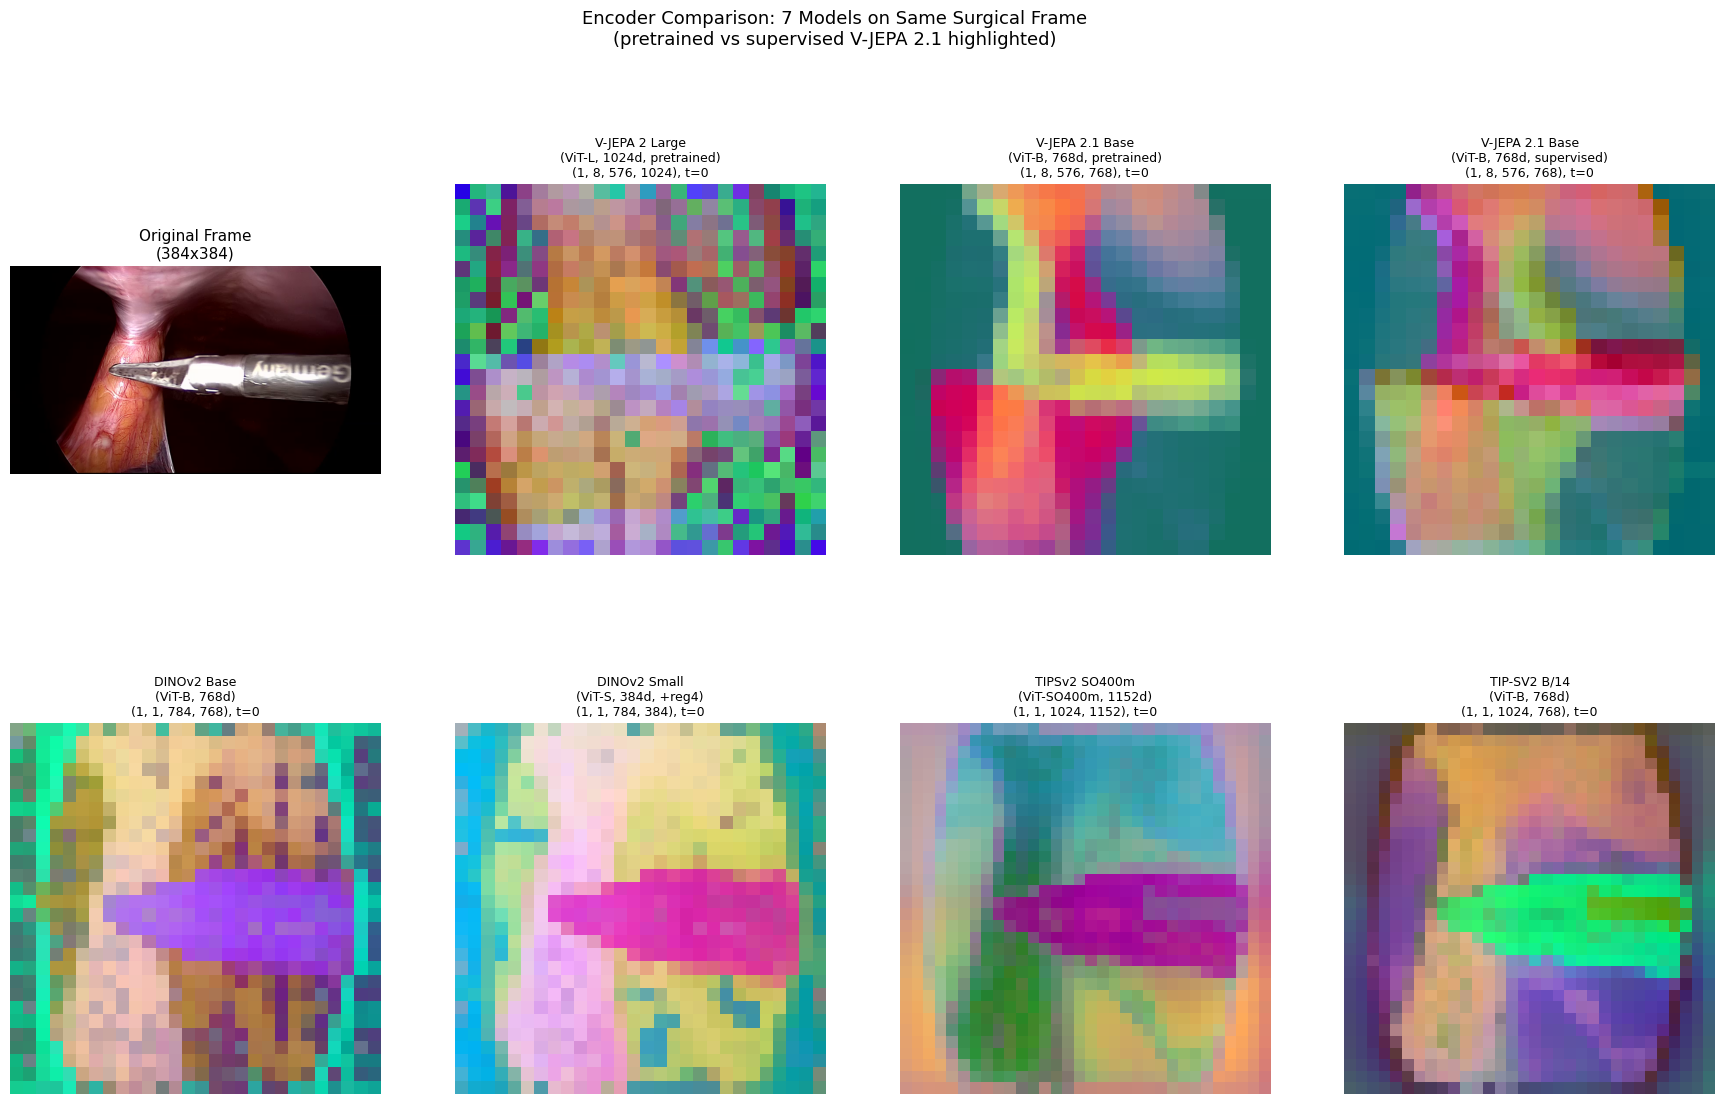


--- Pretrained vs Supervised V-JEPA 2.1 Feature Comparison ---
  Per-token cosine similarity: mean=-0.0241, std=0.0107
  Min: -0.0599, Max: 0.0324
  Per-token L2 distance: mean=39.4429, std=0.2073


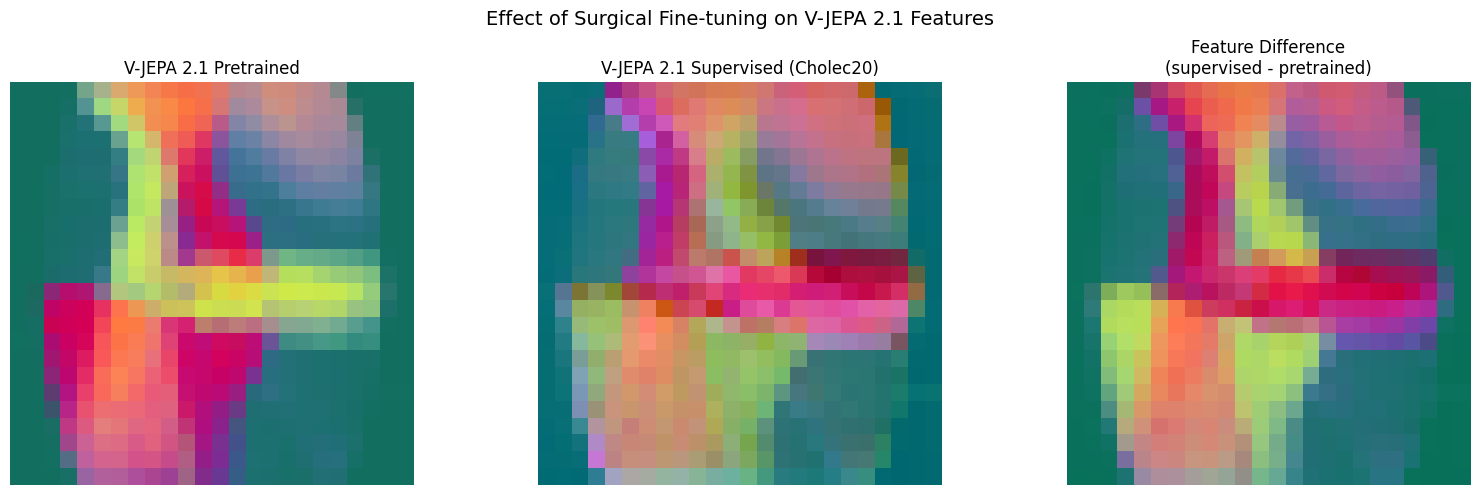


ENCODER COMPARISON SUMMARY — ALL 7 MODELS
Model                               Temporal   Tokens   Dim      Parameters     
-----------------------------------------------------------------------------------------------
V-JEPA 2 Large                      8          576      1024        325,971,328
V-JEPA 2.1 Base                     8          576      768          86,833,152
V-JEPA 2.1 Base                     8          576      768          86,833,152
DINOv2 Base                         1          784      768          86,580,480
DINOv2 Small                        1          784      384          22,058,112
TIPSv2 SO400m                       1          1024     1152        861,726,816
TIP-SV2 B/14                        1          1024     768         195,948,288

--- Zero-Shot Classification Comparison ---

TIPSv2 SO400m Top-5 predictions:
  surgical scene: 0.124
  bipolar: 0.120
  surgical instrument: 0.107
  hook: 0.104
  needle driver: 0.099

TIP-SV2 B/14 Top-5 predictions:
 

In [2]:
# Compare ALL 7 Encoders (including supervised fine-tuned) on same surgical frame
# Shows side-by-side PCA visualizations for all models
# SELF-CONTAINED: includes video loading — run this cell independently

import torch
from pathlib import Path
import torch.nn.functional as F
import sys
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Video loading (self-contained) ---
def load_video_or_frames(input_path, start_frame=0, num_frames=16):
    input_path = Path(input_path)
    if not input_path.is_dir():
        return None, []
    frames_paths = sorted(list(input_path.glob("*.png"))) + sorted(list(input_path.glob("*.jpg")))
    if len(frames_paths) == 0:
        return None, []
    selected_paths = frames_paths[start_frame : start_frame + num_frames]
    frames = []
    original_images = []
    for f in selected_paths:
        img = Image.open(f).convert('RGB')
        original_images.append(np.array(img))
        img_resized = img.resize((384, 384))
        frames.append(transforms.ToTensor()(img_resized))
    video = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0)
    return video.to(DEVICE).to(DTYPE), original_images

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

# --- Load all seven encoders ---

# 1. V-JEPA 2 Large (pretrained on human videos)
print("Loading V-JEPA 2 Large...")
from transformers import VJEPA2Model
vjepa2_base = VJEPA2Model.from_pretrained("facebook/vjepa2-vitl-fpc64-256", torch_dtype=DTYPE)
checkpoint_vjepa2 = torch.load(Path(r"I:\surgi_world_track\vjepa_encoder_human.pt"), map_location='cpu', weights_only=True)
encoder_sd = {k.replace('module.', '').replace('backbone.', ''): v for k, v in checkpoint_vjepa2['encoder'].items()}
vjepa2_base.load_state_dict(encoder_sd, strict=False)
vjepa2_base = vjepa2_base.to(DEVICE).to(DTYPE).eval()
print("  V-JEPA 2 Large: ViT-L 1024d loaded")

# 2. V-JEPA 2.1 Base (pretrained, no surgical fine-tuning)
print("\nLoading V-JEPA 2.1 Base (pretrained)...")
for key in list(sys.modules.keys()):
    if key == 'app' or key.startswith('app.'):
        del sys.modules[key]
hub_result = torch.hub.load('facebookresearch/vjepa2', model='vjepa2_1_vit_base_384', pretrained=False)
if isinstance(hub_result, tuple):
    vjepa21_base = hub_result[0]
else:
    vjepa21_base = hub_result
vjepa21_base = vjepa21_base.to(DEVICE).to(DTYPE).eval()
print("  V-JEPA 2.1 Base (pretrained): ViT-B 768d loaded")

# 3. V-JEPA 2.1 Base (supervised fine-tuned on Cholec20 — from checkpoint)
print("\nLoading V-JEPA 2.1 Base (supervised, Cholec20 fine-tuned)...")
supervised_ckpt = torch.load(
    r'i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar',
    map_location='cpu', weights_only=False
)
supervised_encoder_sd = supervised_ckpt.get('encoder', {})

# Load a fresh V-JEPA 2.1 model and inject supervised weights
for key in list(sys.modules.keys()):
    if key == 'app' or key.startswith('app.'):
        del sys.modules[key]
hub_result_ft = torch.hub.load('facebookresearch/vjepa2', model='vjepa2_1_vit_base_384', pretrained=False)
if isinstance(hub_result_ft, tuple):
    vjepa21_supervised = hub_result_ft[0]
else:
    vjepa21_supervised = hub_result_ft

# Remap supervised checkpoint keys: strip 'backbone.' prefix
supervised_sd_remapped = {k.replace('backbone.', ''): v for k, v in supervised_encoder_sd.items()}
msg = vjepa21_supervised.load_state_dict(supervised_sd_remapped, strict=False)
vjepa21_supervised = vjepa21_supervised.to(DEVICE).to(DTYPE).eval()
print(f"  V-JEPA 2.1 Supervised: ViT-B 768d loaded (epoch {supervised_ckpt.get('epoch', '?')})")
print(f"    Loaded {len(supervised_sd_remapped)} params, missing {len(msg.missing_keys)}, unexpected {len(msg.unexpected_keys)}")

# 4. DINOv2 Base
print("\nLoading DINOv2 Base...")
dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', pretrained=True)
dinov2_base = dinov2_base.to(DEVICE).to(DTYPE).eval()
print("  DINOv2 Base: ViT-B 768d loaded")

# 5. DINOv2 Small with Registers (from local checkpoint)
print("\nLoading DINOv2 Small with 4 registers...")
sys.path.insert(0, r'I:\surgi_world_track\dinov2')
from dinov2.models.vision_transformer import vit_small

dinov2_small_ckpt = torch.load(
    r'I:\surgi_world_track\dinov2_vits14_reg4_pretrain.pth', 
    map_location='cpu', 
    weights_only=True
)

dinov2_small = vit_small(
    patch_size=14, 
    num_register_tokens=4,
    img_size=518,
    init_values=1.0,
    block_chunks=0
)

if 'model' in dinov2_small_ckpt:
    state_dict = dinov2_small_ckpt['model']
else:
    state_dict = dinov2_small_ckpt

dinov2_small.load_state_dict(state_dict, strict=True)
dinov2_small = dinov2_small.to(DEVICE).to(DTYPE).eval()
print(f"  DINOv2 Small: ViT-S 384d with 4 registers loaded")

# 6. TIPSv2 SO400m/14 (Google vision-language model)
print("\nLoading TIPSv2 SO400m/14...")
from transformers import AutoModel
tipsv2 = AutoModel.from_pretrained("google/tipsv2-so400m14", trust_remote_code=True, torch_dtype=DTYPE)
tipsv2 = tipsv2.to(DEVICE).to(DTYPE).eval()
print(f"  TIPSv2: ViT-SO400m 1152d loaded")

# 7. TIP-SV2 B/14 (Google vision-language model, smaller variant)
print("\nLoading TIP-SV2 B/14...")
tipsv2_b14 = AutoModel.from_pretrained("google/tipsv2-b14", trust_remote_code=True, torch_dtype=DTYPE)
tipsv2_b14 = tipsv2_b14.to(DEVICE).to(DTYPE).eval()
print(f"  TIP-SV2 B/14: ViT-B 768d loaded")

# --- Load video ---
VIDEO_PATH = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")
video_tensor, original_frames = load_video_or_frames(VIDEO_PATH, start_frame=0, num_frames=16)
print(f"\nLoaded video: {video_tensor.shape}")

# --- Prepare inputs ---
DINO_SIZE = 392
dino_frame = F.interpolate(video_tensor[0, :, 0:1], size=(DINO_SIZE, DINO_SIZE), mode='bilinear', align_corners=False)
dino_frame = dino_frame.squeeze(1).unsqueeze(0)
dino_small_frame = dino_frame.clone()

TIPS_SIZE = 448
tips_frame = F.interpolate(video_tensor[0, :, 0:1], size=(TIPS_SIZE, TIPS_SIZE), mode='bilinear', align_corners=False)
tips_frame = tips_frame.squeeze(1).unsqueeze(0)
tips_b14_frame = tips_frame.clone()

video_hf = video_tensor.permute(0, 2, 1, 3, 4)  # (B, T, C, H, W)
video_hub = video_tensor  # (B, C, T, H, W)

# --- Extract features with autocast ---
features = {}

# 1. V-JEPA 2 Large
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    out = vjepa2_base(pixel_values_videos=video_hf, skip_predictor=True, output_hidden_states=True)
    feat = out.hidden_states[-1]
    if feat.dim() == 3:
        B, TN, C = feat.shape
        T = 8
        N = TN // T
        feat = feat.reshape(B, T, N, C)
    features['V-JEPA 2 Large\n(ViT-L, 1024d, pretrained)'] = feat
    print(f"V-JEPA 2 Large: {feat.shape}")

# 2. V-JEPA 2.1 Base (pretrained)
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    feat21 = vjepa21_base(video_hub)
    if isinstance(feat21, tuple):
        feat21 = feat21[0]
    if feat21.dim() == 3:
        B, TN, C = feat21.shape
        T_temp = 8
        N = TN // T_temp
        feat21 = feat21.reshape(B, T_temp, N, C)
    features['V-JEPA 2.1 Base\n(ViT-B, 768d, pretrained)'] = feat21
    print(f"V-JEPA 2.1 pretrained: {feat21.shape}")

# 3. V-JEPA 2.1 Base (supervised fine-tuned)
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    feat21_sup = vjepa21_supervised(video_hub)
    if isinstance(feat21_sup, tuple):
        feat21_sup = feat21_sup[0]
    if feat21_sup.dim() == 3:
        B, TN, C = feat21_sup.shape
        T_temp = 8
        N = TN // T_temp
        feat21_sup = feat21_sup.reshape(B, T_temp, N, C)
    features['V-JEPA 2.1 Base\n(ViT-B, 768d, supervised)'] = feat21_sup
    print(f"V-JEPA 2.1 supervised: {feat21_sup.shape}")

# 4. DINOv2 Base
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    dino_out = dinov2_base.forward_features(dino_frame)
    if isinstance(dino_out, dict):
        feat_dino = dino_out['x_norm_patchtokens']
    else:
        feat_dino = dino_out
    feat_dino = feat_dino.unsqueeze(1)
    features['DINOv2 Base\n(ViT-B, 768d)'] = feat_dino
    print(f"DINOv2 Base: {feat_dino.shape}")

# 5. DINOv2 Small with Registers
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    dino_small_out = dinov2_small.forward_features(dino_small_frame)
    if isinstance(dino_small_out, dict):
        feat_dino_small = dino_small_out['x_norm_patchtokens']
    else:
        feat_dino_small = dino_small_out
    feat_dino_small = feat_dino_small.unsqueeze(1)
    features['DINOv2 Small\n(ViT-S, 384d, +reg4)'] = feat_dino_small
    print(f"DINOv2 Small: {feat_dino_small.shape}")

# 6. TIPSv2 SO400m/14
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    tips_out = tipsv2.encode_image(tips_frame)
    feat_tips = tips_out.patch_tokens.unsqueeze(1)  # (1, 1, N, 1152)
    features['TIPSv2 SO400m\n(ViT-SO400m, 1152d)'] = feat_tips
    print(f"TIPSv2: {feat_tips.shape}")

# 7. TIP-SV2 B/14
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    tips_b14_out = tipsv2_b14.encode_image(tips_b14_frame)
    feat_tips_b14 = tips_b14_out.patch_tokens.unsqueeze(1)  # (1, 1, N, 768)
    features['TIP-SV2 B/14\n(ViT-B, 768d)'] = feat_tips_b14
    print(f"TIP-SV2 B/14: {feat_tips_b14.shape}")

# --- Visualize All 7 + Original in 2x4 Grid ---
def viz_features_pca(features, t_idx=0):
    feat_t = features[0, min(t_idx, features.shape[1]-1)]
    feat_np = feat_t.cpu().float().numpy()
    pca = PCA(n_components=3)
    feat_pca = pca.fit_transform(feat_np)
    feat_pca = (feat_pca - feat_pca.min()) / (feat_pca.max() - feat_pca.min() + 1e-8)
    N = feat_pca.shape[0]
    H = W = int(N ** 0.5)
    if H * W != N:
        for h in range(int(N**0.5), 0, -1):
            if N % h == 0:
                H, W = h, N // h
                break
    return feat_pca.reshape(H, W, 3)

fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.2)

# Original frame (top left)
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(original_frames[0])
ax0.set_title("Original Frame\n(384x384)", fontsize=11)
ax0.axis('off')

# Model visualizations — 7 models in remaining slots
model_names = list(features.keys())
positions = [(0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]

for idx, (name, feat) in enumerate(features.items()):
    if idx < len(positions):
        row, col = positions[idx]
        ax = fig.add_subplot(gs[row, col])
        t_idx = 0
        ax.imshow(viz_features_pca(feat, t_idx))
        ax.set_title(f"{name}\n{tuple(feat.shape)}, t={t_idx}", fontsize=9)
        ax.axis('off')

plt.suptitle("Encoder Comparison: 7 Models on Same Surgical Frame\n(pretrained vs supervised V-JEPA 2.1 highlighted)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Pretrained vs Supervised V-JEPA 2.1: Feature Difference ---
print("\n--- Pretrained vs Supervised V-JEPA 2.1 Feature Comparison ---")
pretrained_feat = features['V-JEPA 2.1 Base\n(ViT-B, 768d, pretrained)'][0, 0].cpu().float()  # (N, C)
supervised_feat = features['V-JEPA 2.1 Base\n(ViT-B, 768d, supervised)'][0, 0].cpu().float()  # (N, C)

# Cosine similarity per token
cos_sim = F.cosine_similarity(pretrained_feat, supervised_feat, dim=-1)
print(f"  Per-token cosine similarity: mean={cos_sim.mean():.4f}, std={cos_sim.std():.4f}")
print(f"  Min: {cos_sim.min():.4f}, Max: {cos_sim.max():.4f}")

# L2 distance per token
l2_dist = (pretrained_feat - supervised_feat).norm(dim=-1)
print(f"  Per-token L2 distance: mean={l2_dist.mean():.4f}, std={l2_dist.std():.4f}")

# PCA of the *difference* features
diff_feat = (supervised_feat - pretrained_feat).numpy()
pca_diff = PCA(n_components=3)
diff_pca = pca_diff.fit_transform(diff_feat)
diff_pca = (diff_pca - diff_pca.min()) / (diff_pca.max() - diff_pca.min() + 1e-8)
N = diff_pca.shape[0]
H = W = int(N ** 0.5)
if H * W != N:
    for h in range(int(N**0.5), 0, -1):
        if N % h == 0:
            H, W = h, N // h
            break
diff_img = diff_pca.reshape(H, W, 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(viz_features_pca(features['V-JEPA 2.1 Base\n(ViT-B, 768d, pretrained)']))
axes[0].set_title("V-JEPA 2.1 Pretrained", fontsize=12)
axes[0].axis('off')

axes[1].imshow(viz_features_pca(features['V-JEPA 2.1 Base\n(ViT-B, 768d, supervised)']))
axes[1].set_title("V-JEPA 2.1 Supervised (Cholec20)", fontsize=12)
axes[1].axis('off')

axes[2].imshow(diff_img)
axes[2].set_title("Feature Difference\n(supervised - pretrained)", fontsize=12)
axes[2].axis('off')

plt.suptitle("Effect of Surgical Fine-tuning on V-JEPA 2.1 Features", fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n" + "="*95)
print("ENCODER COMPARISON SUMMARY — ALL 7 MODELS")
print("="*95)
print(f"{'Model':<35} {'Temporal':<10} {'Tokens':<8} {'Dim':<8} {'Parameters':<15}")
print("-"*95)

model_params = [
    sum(p.numel() for p in vjepa2_base.parameters()),
    sum(p.numel() for p in vjepa21_base.parameters()),
    sum(p.numel() for p in vjepa21_supervised.parameters()),
    sum(p.numel() for p in dinov2_base.parameters()),
    sum(p.numel() for p in dinov2_small.parameters()),
    sum(p.numel() for p in tipsv2.parameters()),
    sum(p.numel() for p in tipsv2_b14.parameters()),
]

for (name, feat), params in zip(features.items(), model_params):
    B, T, N, C = feat.shape if feat.dim() == 4 else (feat.shape[0], 1, feat.shape[1], feat.shape[2])
    clean_name = name.split('\n')[0]
    print(f"{clean_name:<35} {T:<10} {N:<8} {C:<8} {params:>14,}")

print("="*95)

# --- Zero-Shot Classification Demo for TIPS models ---
print("\n--- Zero-Shot Classification Comparison ---")
surgical_classes = [
    "grasper", "bipolar", "hook", "scissors", "clipper",
    "specimen bag", "needle driver", "surgical instrument", "surgical scene", "background"
]

# TIPSv2 SO400m
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    cls_token_so400m = tips_out.cls_token[:, 0, :]
    text_emb_so400m = tipsv2.encode_text(surgical_classes)
    cls_norm = F.normalize(cls_token_so400m, dim=-1)
    text_norm = F.normalize(text_emb_so400m, dim=-1)
    similarity = (cls_norm @ text_norm.T).squeeze(0)
    top5_vals, top5_idx = similarity.topk(5)
    print("\nTIPSv2 SO400m Top-5 predictions:")
    for i in range(5):
        print(f"  {surgical_classes[top5_idx[i]]}: {top5_vals[i].item():.3f}")

# TIP-SV2 B/14
with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
    cls_token_b14 = tips_b14_out.cls_token[:, 0, :]
    text_emb_b14 = tipsv2_b14.encode_text(surgical_classes)
    cls_norm = F.normalize(cls_token_b14, dim=-1)
    text_norm = F.normalize(text_emb_b14, dim=-1)
    similarity = (cls_norm @ text_norm.T).squeeze(0)
    top5_vals, top5_idx = similarity.topk(5)
    print("\nTIP-SV2 B/14 Top-5 predictions:")
    for i in range(5):
        print(f"  {surgical_classes[top5_idx[i]]}: {top5_vals[i].item():.3f}")

Loading vjepa2_1_vit_base_384 via torch.hub ...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


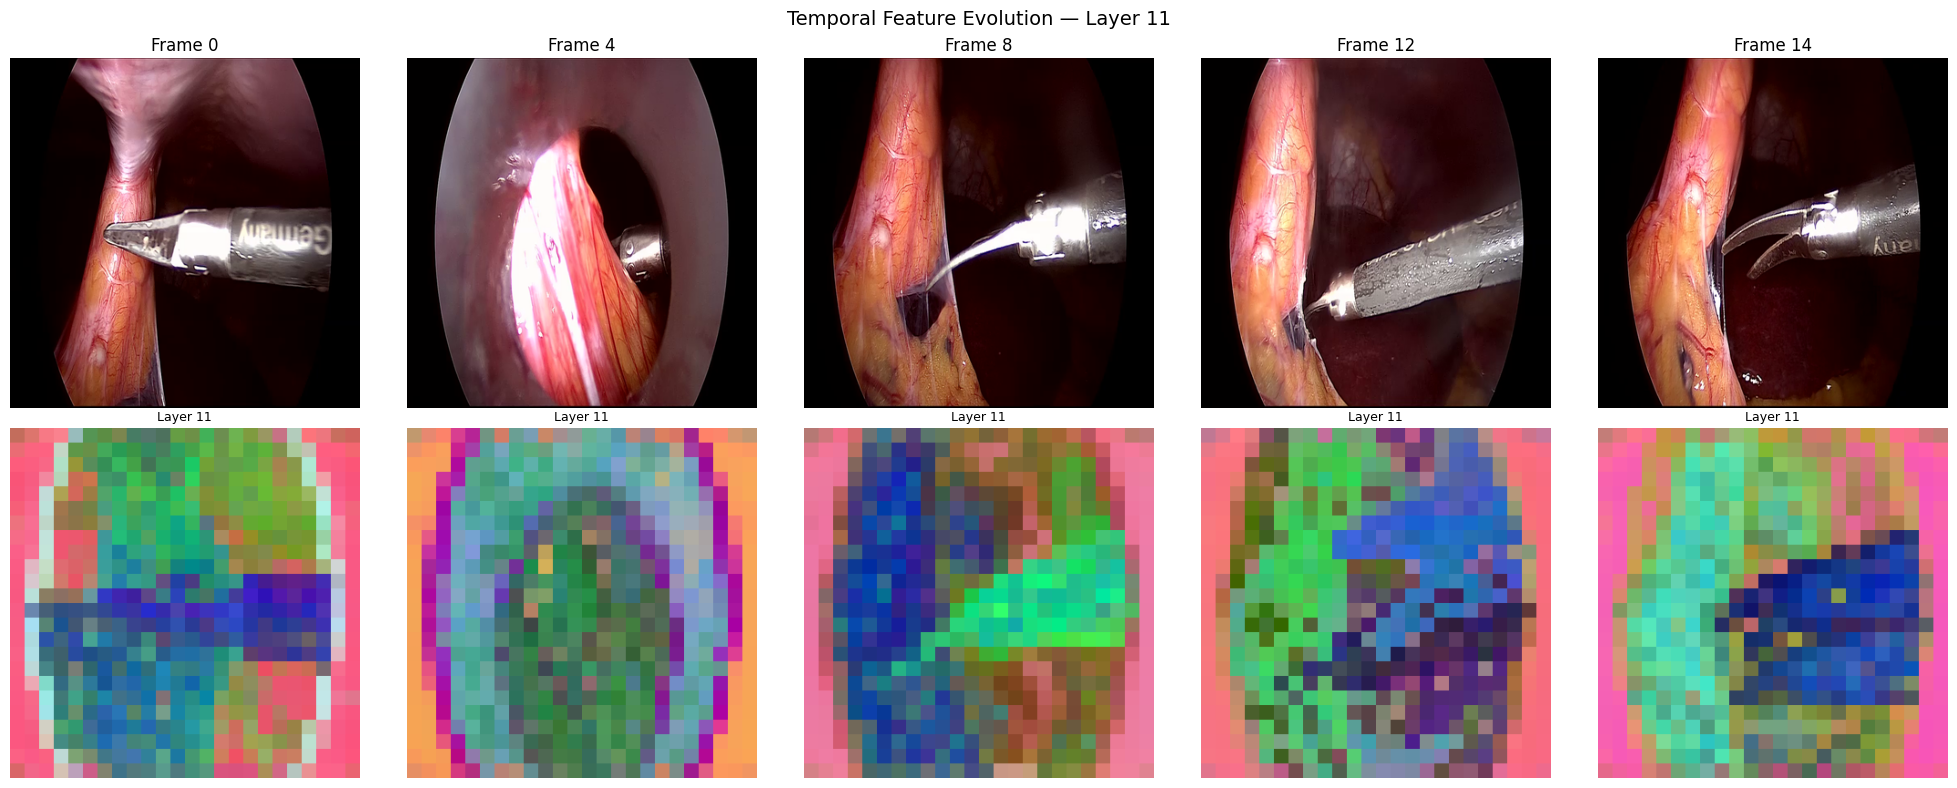

: 

In [ ]:
# Test loading the SurgicalTrackingSystem with the fixed function
from pathlib import Path
import torch

CHECKPOINT_PATH = Path(r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar")
VIDEO_PATH = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")

if not CHECKPOINT_PATH.exists():
    print(f"❌ Checkpoint not found: {CHECKPOINT_PATH}")
elif not VIDEO_PATH.exists():
    print(f"❌ Video path not found: {VIDEO_PATH}")
else:
    print(f"✓ Found checkpoint: {CHECKPOINT_PATH.name}")
    print(f"✓ Found video: {VIDEO_PATH.name}")
    
    # Load the model with V-JEPA 2.1 (use_vjepa21=True)
    print("\n[1/3] Loading SurgicalTrackingSystem...")
    try:
        model = load_vjepa_world_model_fixed(str(CHECKPOINT_PATH), use_vjepa21=True)
        model = model.to(DEVICE)
        model.eval()
        print(f"   ✓ Model loaded on {DEVICE}")
        print(f"   - Encoder dim: {model.encoder_dim}")
        print(f"   - Num tools: {model.num_tools}")
    except Exception as e:
        print(f"   ❌ Error loading model: {e}")
        import traceback
        traceback.print_exc()
        model = None
    
    if model is not None:
        # Load a video segment
        print("\n[2/3] Loading video frames...")
        video_tensor, original_frames = load_video_or_frames(VIDEO_PATH, start_frame=0, num_frames=16)
        
        if video_tensor is None:
            print("   ❌ Could not load video.")
        else:
            print(f"   ✓ Video loaded: {video_tensor.shape}")
            print(f"   - Dtype: {video_tensor.dtype}")
            print(f"   - Device: {video_tensor.device}")
            
            # Run inference
            print("\n[3/3] Running inference...")
            try:
                with torch.no_grad():
                    with torch.autocast(DEVICE, dtype=DTYPE):
                        outputs = model(video_tensor, mode='inference')
                
                print(f"   ✓ Inference complete!")
                print(f"\n   Output keys: {list(outputs.keys())}")
                
                if 'detr_logits' in outputs:
                    print(f"   - Detection logits: {outputs['detr_logits'].shape}")
                if 'detr_boxes' in outputs:
                    print(f"   - Detection boxes: {outputs['detr_boxes'].shape}")
                if 'reid_embeddings' in outputs:
                    print(f"   - ReID embeddings: {outputs['reid_embeddings'].shape}")
                    
                # Show detection results
                if 'detr_logits' in outputs and outputs['detr_logits'] is not None:
                    probs = torch.softmax(outputs['detr_logits'], dim=-1)
                    conf, cls = probs.max(dim=-1)
                    print(f"\n   Top detections:")
                    for i in range(min(3, len(conf[0]))):
                        print(f"     Query {i}: Tool {cls[0, i].item()}, conf={conf[0, i].item():.3f}")
                    
            except Exception as e:
                print(f"   ❌ Error during inference: {e}")
                import traceback
                traceback.print_exc()

In [ ]:
# Definitive Checkpoint Inspection
# This script loads the checkpoint and identifies exactly which heads are present.

import torch
import os
from pathlib import Path

# Fix for potential OpenMP conflict
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

CHECKPOINT_PATH = Path(r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar")

if CHECKPOINT_PATH.exists():
    print(f"Analyzing: {CHECKPOINT_PATH.name}")
    # Load with weights_only=False to see dict structure
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
    
    keys = list(checkpoint.keys())
    print(f"\nFound keys: {keys}")
    
    # Check for components
    has_encoder = 'encoder' in checkpoint
    has_predictor = 'predictor' in checkpoint
    has_detr = any(k in checkpoint for k in ['detr', 'detr_head'])
    has_reid = any(k in checkpoint for k in ['reid', 'reid_head'])
    
    print("-" * 30)
    print(f"ENCODER:   {'[YES]' if has_encoder else '[NO ]'}")
    print(f"PREDICTOR: {'[YES]' if has_predictor else '[NO ]'}")
    print(f"DETR HEAD: {'[YES]' if has_detr else '[NO ]'}")
    print(f"REID HEAD: {'[YES]' if has_reid else '[NO ]'}")
    print("-" * 30)

    if has_encoder:
        enc_keys = list(checkpoint['encoder'].keys())
        print(f"Encoder params: {len(enc_keys)}")
        # Check for DINOv2 vs V-JEPA markers
        is_dinov2 = any('dinov2' in k.lower() for k in enc_keys) or any('mask_token' in k for k in enc_keys)
        print(f"DINOv2 likely: {is_dinov2}")
        
    if has_detr:
        detr_key = 'detr_head' if 'detr_head' in checkpoint else 'detr'
        print(f"DETR Head params: {len(checkpoint[detr_key])}")

    if has_reid:
        reid_key = 'reid_head' if 'reid_head' in checkpoint else 'reid'
        print(f"ReID Head params: {len(checkpoint[reid_key])}")

else:
    print(f"File not found: {CHECKPOINT_PATH}")

Analyzing: latest-supervised.pth.tar

Found keys: ['epoch', 'encoder', 'predictor', 'detr_head', 'reid_head', 'opt']
------------------------------
ENCODER:   [YES]
PREDICTOR: [YES]
DETR HEAD: [YES]
REID HEAD: [YES]
------------------------------
Encoder params: 158
DINOv2 likely: False
DETR Head params: 100
ReID Head params: 4


In [ ]:
# --- Selective Loading: DINOv2 Encoder + Predictor ---
# This cell extracts only the needed components from the full checkpoint.

import torch
from core_app.models.vjepa_world_model import WorldModel

# 1. Config and Paths
CKPT_PATH = r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading checkpoint: {CKPT_PATH}")
full_ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

# 2. Extract specific state dicts
encoder_sd = full_ckpt.get('encoder', {})
predictor_sd = full_ckpt.get('predictor', {})

# Detect dimensions for initialization
if 'class_head.bias' in full_ckpt.get('detr_head', {}):
    num_tools = full_ckpt['detr_head']['class_head.bias'].shape[0]
else:
    num_tools = 7 # Default

# Determine encoder dimension from weights
encoder_dim = 768 # Default for base
if 'mask_token' in encoder_sd:
    encoder_dim = encoder_sd['mask_token'].shape[0]

print(f"Detected Encoder Dim: {encoder_dim}")
print(f"Encoder params: {len(encoder_sd)}")
print(f"Predictor params: {len(predictor_sd)}")

# 3. Instantiate clean WorldModel (No DETR/ReID)
# Note: WorldModel contains (encoder, encoder_neck, predictor)
world_model = WorldModel(
    encoder_type='vjepa', # Based on the checkpoint name 'base384'
    model_name='vjepa2_1_vit_base_384',
    encoder_dim=encoder_dim,
    predictor_embed_dim=encoder_dim,
    use_torch_hub=True
).to(DEVICE)

# 4. Load weights selectively
# We need to map the top-level 'encoder' and 'predictor' keys into the WorldModel
# In SurgicalTrackingSystem, world_model has: .encoder, .encoder_neck, .predictor
msg_enc = world_model.encoder.load_state_dict(encoder_sd, strict=False)
msg_pred = world_model.predictor.load_state_dict(predictor_sd, strict=False)

print("\nSelective Loading Summary:")
print(f"  Encoder:   Missing={len(msg_enc.missing_keys)}, Unexpected={len(msg_enc.unexpected_keys)}")
print(f"  Predictor: Missing={len(msg_pred.missing_keys)}, Unexpected={len(msg_pred.unexpected_keys)}")

world_model.eval()
print("\n[SUCCESS] WorldModel (Encoder + Predictor) ready without DETR/ReID heads.")

Loading checkpoint: i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar
Detected Encoder Dim: 768
Encoder params: 158


TypeError: object of type 'NoneType' has no len()

In [ ]:
# Fixed load_vjepa_world_model function that detects encoder_dim and reid_input_dim from checkpoint

import sys
from pathlib import Path
import torch

# Add project root to path
project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.append(project_root)

def load_vjepa_world_model_fixed(checkpoint_path: str, use_vjepa21=False):
    """Load the full Surgical Tracking System with automatic dimension detection.
    
    Args:
        checkpoint_path: Path to the checkpoint file
        use_vjepa21: If True, use V-JEPA 2.1 from torch.hub (768 dim). If False, use V-JEPA 2 from HF (1024 dim).
    
    Returns:
        Loaded SurgicalTrackingSystem model
    """
    import importlib
    import core_app.models.detr_head
    import core_app.models.reid_head
    import core_app.models.temporal_predictor
    import core_app.models.vjepa_world_model
    importlib.reload(core_app.models.detr_head)
    importlib.reload(core_app.models.reid_head)
    importlib.reload(core_app.models.temporal_predictor)
    importlib.reload(core_app.models.vjepa_world_model)

    from core_app.models.vjepa_world_model import SurgicalTrackingSystem

    print(f"Loading Surgical Tracking System from {checkpoint_path} ...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    # Detect architecture from checkpoint
    detr_sd = checkpoint.get('detr_head', checkpoint.get('detr', {}))
    num_tools, num_pos_tokens, has_bbox = 7, 4608, False
    encoder_dim = 768  # Default to V-JEPA 2.1 Base
    reid_input_dim = None  # Will be detected from reid.embedding.weight
    
    if detr_sd:
        if 'class_head.bias' in detr_sd:
            num_tools = detr_sd['class_head.bias'].shape[0]
        elif 'class_embed.bias' in detr_sd:
            num_tools = detr_sd['class_embed.bias'].shape[0]
        if 'pos_embed.weight' in detr_sd:
            num_pos_tokens = detr_sd['pos_embed.weight'].shape[0]
        has_bbox = any(k.startswith('bbox_head.') or k.startswith('bbox_embed.') for k in detr_sd)
        
        # Detect encoder_dim from DETR query_embed
        if 'query_embed.weight' in detr_sd:
            encoder_dim = detr_sd['query_embed.weight'].shape[1]
    
    # Detect reid_input_dim from reid.embedding.weight
    reid_sd = checkpoint.get('reid_head', checkpoint.get('reid', {}))
    if reid_sd and 'embedding.weight' in reid_sd:
        reid_input_dim = reid_sd['embedding.weight'].shape[1]
    
    print(f"  Detected: num_tools={num_tools}, num_pos_tokens={num_pos_tokens}, has_bbox={has_bbox}")
    print(f"  Detected: encoder_dim={encoder_dim}, reid_input_dim={reid_input_dim}")
    
    # Set model name and encoder type based on use_vjepa21 flag
    if use_vjepa21:
        model_name = 'vjepa2_1_vit_base_384'
        print(f"  Using V-JEPA 2.1 from torch.hub: {model_name}")
    else:
        model_name = "facebook/vjepa2-vitl-fpc64-256"
        print(f"  Using V-JEPA 2 from HuggingFace: {model_name}")
    
    # Build model with detected dimensions
    model = SurgicalTrackingSystem(
        encoder_type='vjepa',
        model_name=model_name,
        encoder_dim=encoder_dim,
        reid_input_dim=reid_input_dim,
        num_frames=16,
        img_size=IMG_SIZE,
        num_tools=num_tools,
        detr_max_pos_tokens=num_pos_tokens,
        detr_dim_feedforward=2048,
        detr_bbox_weight=1.0 if has_bbox else 0.0,
        use_torch_hub=use_vjepa21,
    )

    # Remap state dict keys
    new_state_dict = {}
    predictor_sd = checkpoint.get('predictor')
    if predictor_sd and isinstance(predictor_sd, dict):
        for k, v in predictor_sd.items():
            new_state_dict[f'world_model.predictor.{k}'] = v
    detr_key = next((k for k in ['detr_head', 'detr', 'detr_head_state_dict'] if k in checkpoint), None)
    if detr_key:
        for k, v in checkpoint[detr_key].items():
            # Simple key remapping for DETR
            if k.startswith('class_head.'):
                new_state_dict[f'detr.{k}'] = v
            elif k.startswith('bbox_head.'):
                new_state_dict[f'detr.{k}'] = v
            elif k.startswith('query_embed.'):
                new_state_dict[f'detr.{k}'] = v
            else:
                new_state_dict[f'detr.{k}'] = v
    reid_key = next((k for k in ['reid_head', 'reid', 'reid_head_state_dict'] if k in checkpoint), None)
    if reid_key:
        for k, v in checkpoint[reid_key].items():
            new_state_dict[f'reid.{k}'] = v
    encoder_sd = checkpoint.get('encoder')
    if encoder_sd and isinstance(encoder_sd, dict):
        for k, v in encoder_sd.items():
            new_state_dict[f'world_model.encoder.encoder.{k.replace("backbone.", "")}'] = v
    for key in ['epoch', 'reid_weight']:
        val = checkpoint.get(key)
        if val is not None:
            new_state_dict[key] = torch.as_tensor(val)
    if not new_state_dict:
        new_state_dict = checkpoint.get('model', checkpoint.get('model_state_dict', checkpoint))

    loaded_prefixes = sorted({'.'.join(k.split('.')[:2]) for k in new_state_dict})
    print(f"  Remapped key prefixes: {loaded_prefixes}")
    msg = model.load_state_dict(new_state_dict, strict=False)
    n_miss, n_unexp = len(msg.missing_keys), len(msg.unexpected_keys)
    print(f"  Missing keys: {n_miss}, Unexpected keys: {n_unexp}")
    truly_missing = [k for k in msg.missing_keys
                     if not k.startswith('world_model.predictor.') and not k.startswith('detr.criterion.')]
    if truly_missing:
        print(f"  Truly missing (excl. predictor/criterion): {truly_missing[:10]}")
    
    if n_unexp > 0:
        print(f"  Unexpected keys (first 10): {msg.unexpected_keys[:10]}")

    return model.to(DEVICE).to(DTYPE).eval()

print("Fixed load_vjepa_world_model function defined.")

Fixed load_vjepa_world_model function defined.


In [ ]:
# Test loading the SurgicalTrackingSystem with the fixed function

from pathlib import Path

CHECKPOINT_PATH = Path(r"i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar")
VIDEO_PATH = Path(r"i:\surgi_world_track\data\cholectrack20\training\vid02\frames")

if CHECKPOINT_PATH.exists() and VIDEO_PATH.exists():
    # Load the model with V-JEPA 2.1 (use_vjepa21=True)
    model = load_vjepa_world_model_fixed(str(CHECKPOINT_PATH), use_vjepa21=True)
    
    # Load a video segment
    video_tensor, original_frames = load_video_or_frames(VIDEO_PATH, start_frame=0, num_frames=16)
    
    if video_tensor is not None:
        print(f"\nLoaded video: {video_tensor.shape}")
        
        # Run inference
        with torch.no_grad():
            outputs = model(video_tensor, mode='inference')
        
        print(f"\nInference outputs keys: {outputs.keys()}")
        print(f"Detection logits shape: {outputs['detr_logits'].shape}")
        print(f"Detection boxes shape: {outputs['detr_boxes'].shape}")
    else:
        print("Could not load video.")
else:
    print(f"Checkpoint or video path not found.")

Loading Surgical Tracking System from i:\surgi_world_track\checkpoints\cholec20\supervised_detr_reid_base384\latest-supervised.pth.tar ...
  Detected: num_tools=7, num_pos_tokens=4608, has_bbox=True
  Detected: encoder_dim=768, reid_input_dim=768
  Using V-JEPA 2.1 from torch.hub: vjepa2_1_vit_base_384
Loading V-JEPA 2.1 from torch.hub: facebookresearch/vjepa2:vjepa2_1_vit_base_384


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


V-JEPA encoder frozen
  Remapped key prefixes: ['detr.bbox_head', 'detr.class_head', 'detr.decoder', 'detr.pos_embed', 'detr.query_embed', 'detr.track_embed', 'epoch', 'reid.classifier', 'reid.embedding', 'world_model.encoder']
  Missing keys: 261, Unexpected keys: 102
  Truly missing (excl. predictor/criterion): ['reid_weight', 'world_model.encoder_neck.neck.temporal_weights', 'world_model.encoder_neck.neck.proj.0.weight', 'world_model.encoder_neck.neck.proj.1.weight', 'world_model.encoder_neck.neck.proj.1.bias', 'world_model.encoder_neck.neck.refine.weight', 'detr.input_proj.weight', 'detr.input_proj.bias', 'detr.detr_head.decoder.query_embed.weight', 'detr.detr_head.decoder.track_embed.weight']
  Unexpected keys (first 10): ['detr.query_embed.weight', 'detr.pos_embed.weight', 'detr.decoder.layers.0.self_attn.in_proj_weight', 'detr.decoder.layers.0.self_attn.in_proj_bias', 'detr.decoder.layers.0.self_attn.out_proj.weight', 'detr.decoder.layers.0.self_attn.out_proj.bias', 'detr.decode

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x256 and 768x256)

In [ ]:
# V-JEPA 2 feature distribution in PCA space
def plot_pca_scatter(pcas, features_list, title="Layer-wise PCA Feature Distribution"):
    """Plot PCA scatter for each layer."""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for i, (pca, feat, ax) in enumerate(zip(pcas, features_list, axes)):
        if isinstance(feat, (list, tuple)):
            feat = feat[0]
        # Take first frame
        feat_frame = feat[0, 0].cpu().float().numpy()  # (N, C)
        feat_pca = pca.transform(feat_frame)
        
        scatter = ax.scatter(feat_pca[:, 0], feat_pca[:, 1], c=feat_pca[:, 2], cmap='viridis', s=1)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        ax.set_title(f'Layer {LAYER_INDICES[i]}')
        plt.colorbar(scatter, ax=ax, label='PC3')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_pca_scatter(vjepa_pcas, vjepa_features, title="V-JEPA 2 Layer-wise PCA Feature Distribution")

NameError: name 'vjepa_pcas' is not defined

In [ ]:
# V-JEPA 2 layer statistics
def print_layer_statistics(features_list, title="Layer-wise Feature Statistics"):
    """Print statistics for each layer's features."""
    print(f"\n{title}")
    print("=" * 60)
    for i, feat in enumerate(features_list):
        if isinstance(feat, (list, tuple)):
            feat = feat[0]
        feat_np = feat.cpu().float().numpy()
        print(f"\nLayer {LAYER_INDICES[i]}:")
        print(f"  Shape: {feat_np.shape}")
        print(f"  Mean: {feat_np.mean():.4f}")
        print(f"  Std: {feat_np.std():.4f}")
        print(f"  Min: {feat_np.min():.4f}")
        print(f"  Max: {feat_np.max():.4f}")

print_layer_statistics(vjepa_features, title="V-JEPA 2 Layer-wise Feature Statistics")

NameError: name 'vjepa_features' is not defined

In [ ]:
def compute_layer_pca(features):
    """Compute PCA for each layer's features."""
    pcas = []
    for feat in features:
        # Flatten spatial and temporal dimensions
        if feat.dim() == 4:  # (B, T, HW, C)
            feat_flat = feat.reshape(-1, feat.shape[-1])
        elif feat.dim() == 3:  # (B, T*HW, C) or (B, HW, C)
            feat_flat = feat.reshape(-1, feat.shape[-1])
        else:
            feat_flat = feat.reshape(-1, 1) if feat.dim() == 1 else feat.flatten().unsqueeze(1)
        
        pca = PCA(n_components=min(10, feat_flat.shape[0], feat_flat.shape[1]))
        pca.fit(feat_flat.cpu().float().numpy())
        pcas.append(pca)
    return pcas

def plot_explained_variance(pcas, title="Layer-wise PCA Explained Variance"):
    """Plot explained variance ratio for each layer."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, pca in enumerate(pcas):
        ax = axes[i]
        ax.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
        ax.set_xlabel('Principal Component')
        ax.set_ylabel('Explained Variance Ratio')
        ax.set_title(f'Layer {LAYER_INDICES[i]}')
        ax.grid(alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_pca_scatter(pcas, features, title="Layer-wise PCA Feature Distribution"):
    """Plot PCA scatter plots for each layer."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, (pca, feat) in enumerate(zip(pcas, features)):
        ax = axes[i]
        # Flatten features
        if feat.dim() == 4:
            feat_flat = feat.reshape(-1, feat.shape[-1])
        elif feat.dim() == 3:
            feat_flat = feat.reshape(-1, feat.shape[-1])
        else:
            feat_flat = feat.reshape(-1, 1)
        
        # Transform with PCA
        transformed = pca.transform(feat_flat.cpu().float().numpy()[:1000])  # Sample 1000 points
        scatter = ax.scatter(transformed[:, 0], transformed[:, 1], alpha=0.5, s=10)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_title(f'Layer {LAYER_INDICES[i]}')
        ax.grid(alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def print_layer_statistics(features, title="Layer-wise Feature Statistics"):
    """Print statistics for each layer's features."""
    print(f"\n{title}")
    print("=" * 60)
    for i, feat in enumerate(features):
        if feat.dim() == 4:
            feat_flat = feat.reshape(-1, feat.shape[-1])
        elif feat.dim() == 3:
            feat_flat = feat.reshape(-1, feat.shape[-1])
        else:
            feat_flat = feat.flatten()
        
        feat_np = feat_flat.cpu().float().numpy()
        print(f"\nLayer {LAYER_INDICES[i]}:")
        print(f"  Shape: {feat.shape}")
        print(f"  Mean: {feat_np.mean():.6f}")
        print(f"  Std: {feat_np.std():.6f}")
        print(f"  Min: {feat_np.min():.6f}")
        print(f"  Max: {feat_np.max():.6f}")

def plot_layer_similarity(features, title="Layer-wise Feature Similarity"):
    """Plot cosine similarity between layers."""
    n_layers = len(features)
    similarity_matrix = np.zeros((n_layers, n_layers))
    
    for i in range(n_layers):
        for j in range(n_layers):
            # Flatten features
            feat_i = features[i].reshape(-1, features[i].shape[-1]).cpu().float().numpy()
            feat_j = features[j].reshape(-1, features[j].shape[-1]).cpu().float().numpy()
            
            # Sample to same size
            min_size = min(feat_i.shape[0], feat_j.shape[0])
            feat_i = feat_i[:min_size]
            feat_j = feat_j[:min_size]
            
            # Compute cosine similarity
            feat_i_flat = feat_i.flatten()
            feat_j_flat = feat_j.flatten()
            similarity = np.dot(feat_i_flat, feat_j_flat) / (np.linalg.norm(feat_i_flat) * np.linalg.norm(feat_j_flat) + 1e-8)
            similarity_matrix[i, j] = similarity
    
    plt.figure(figsize=(8, 6))
    plt.imshow(similarity_matrix, cmap='viridis', vmin=-1, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.xticks(range(n_layers), [f'L{LAYER_INDICES[i]}' for i in range(n_layers)])
    plt.yticks(range(n_layers), [f'L{LAYER_INDICES[i]}' for i in range(n_layers)])
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# V-JEPA 2 layer statistics
print_layer_statistics(vjepa_features, title="V-JEPA 2 Layer-wise Feature Statistics")

NameError: name 'vjepa_features' is not defined

In [15]:
# --- Comprehensive Layer-wise PCA Analysis: All 3 Encoders ---
# Compares V-JEPA 2 Large, V-JEPA 2.1 Base, and DINOv2 Base
# Extracts features from intermediate layers and visualizes PCA distributions

from sklearn.decomposition import PCA
import torch.nn.functional as F
from transformers import VJEPA2Model

print("=" * 70)
print("COMPREHENSIVE LAYER-WISE FEATURE EXTRACTION: ALL ENCODERS")
print("=" * 70)

# --- Layer indices for each model ---
VJEPA2_LAYERS = [6, 12, 18, 24]      # V-JEPA 2 Large has 24 layers
VJEPA21_LAYERS = [3, 6, 9, 12]       # V-JEPA 2.1 Base has 12 layers  
DINOV2_LAYERS = [3, 6, 9, 12]        # DINOv2 Base has 12 layers

# --- Load all 3 encoders ---
print("\n[1/4] Loading encoders...")

# 1. V-JEPA 2 Large (HuggingFace)
print("  Loading V-JEPA 2 Large (ViT-L/16, 1024d, 24 layers)...")
vjepa2_large = VJEPA2Model.from_pretrained("facebook/vjepa2-vitl-fpc64-256", torch_dtype=DTYPE)
checkpoint_vjepa2 = torch.load(VJ_2_CHECKPOINT, map_location='cpu', weights_only=True)
encoder_sd = {k.replace('module.', '').replace('backbone.', ''): v for k, v in checkpoint_vjepa2['encoder'].items()}
vjepa2_large.load_state_dict(encoder_sd, strict=False)
vjepa2_large = vjepa2_large.to(DEVICE).to(DTYPE).eval()
print(f"    ✓ Loaded: {sum(p.numel() for p in vjepa2_large.parameters()):,} params")

# 2. V-JEPA 2.1 Base (torch.hub)
print("  Loading V-JEPA 2.1 Base (ViT-B/16, 768d, 12 layers)...")
vjepa21_result = torch.hub.load('facebookresearch/vjepa2:main', 'vjepa2_1_vit_base_384', trust_repo=True)
vjepa21_base = vjepa21_result[0] if isinstance(vjepa21_result, tuple) else vjepa21_result
vjepa21_base = vjepa21_base.to(DEVICE).to(DTYPE).eval()
print(f"    ✓ Loaded: {sum(p.numel() for p in vjepa21_base.parameters()):,} params")

# 3. DINOv2 Base (torch.hub)
print("  Loading DINOv2 Base (ViT-B/14, 768d, 12 layers)...")
dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', pretrained=True)
dinov2_base = dinov2_base.to(DEVICE).to(DTYPE).eval()
print(f"    ✓ Loaded: {sum(p.numel() for p in dinov2_base.parameters()):,} params")

# --- Prepare video inputs ---
print("\n[2/4] Preparing video inputs...")
video_tensor, original_frames = load_video_or_frames(VIDEO_DIR, start_frame=0, num_frames=16)
print(f"  Video loaded: {video_tensor.shape}")

# V-JEPA 2 (HF): (B, T, C, H, W)
video_vjepa2 = video_tensor.permute(0, 2, 1, 3, 4)

# V-JEPA 2.1: (B, C, T, H, W) - already correct
video_vjepa21 = video_tensor

# DINOv2: single frame, 392x392 (divisible by 14)
DINO_SIZE = 392
dino_frame = F.interpolate(video_tensor[0, :, 0:1], size=(DINO_SIZE, DINO_SIZE), mode='bilinear', align_corners=False)
dino_frame = dino_frame.squeeze(1).unsqueeze(0)  # (1, C, 392, 392)
print(f"  DINOv2 input: {dino_frame.shape}")

# --- Feature extraction functions ---

def get_vjepa2_layer_features(model, video_input, layer_indices):
    """Extract intermediate layer features from V-JEPA 2 (HuggingFace).
    
    Uses output_hidden_states=True to get all layer outputs.
    V-JEPA 2: 24 layers, 1024 dim, (B, T, N, C) output format.
    """
    features = []
    with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
        outputs = model(pixel_values_videos=video_input, skip_predictor=True, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # Tuple of (num_layers+1) tensors
        
        # hidden_states[0] is embedding layer, hidden_states[1:] are transformer layers
        for idx in layer_indices:
            feat = hidden_states[idx]  # (B, T, N, C) or (B, TN, C)
            
            # Reshape if flattened
            if feat.dim() == 3:
                B, TN, C = feat.shape
                # V-JEPA 2: tubelet_size=2, so T = num_frames // 2 = 8
                T = 8
                N = TN // T
                feat = feat.reshape(B, T, N, C)
            
            features.append(feat)
            print(f"    Layer {idx}: {feat.shape}")
    
    return features

def get_vjepa21_layer_features(model, video_input, layer_indices):
    """Extract intermediate layer features from V-JEPA 2.1 (torch.hub).
    
    Manually runs through blocks to capture intermediate outputs.
    V-JEPA 2.1: 12 layers, 768 dim, uses RoPE (no pos_embed).
    """
    features = []
    
    with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
        B, C, T, H, W = video_input.shape
        
        # Compute patch dimensions
        T_patches = T // model.tubelet_size
        H_patches = H // model.patch_size
        W_patches = W // model.patch_size
        
        # Patch embedding
        x = model.patch_embed(video_input)
        
        # Add video modality embedding
        if model.modality_embedding:
            x += model.video_mod_embed.repeat(x.shape[0], 1, 1)
        
        # Run through blocks, capturing intermediate outputs
        for i, block in enumerate(model.blocks):
            x, _ = block(x, T=T_patches, H_patches=H_patches, W_patches=W_patches)
            
            if (i + 1) in layer_indices:
                N_spatial = H_patches * W_patches
                feat = x.reshape(B, T_patches, N_spatial, x.shape[-1])
                features.append(feat)
                print(f"    Layer {i+1}: {feat.shape}")
    
    return features

def get_dinov2_layer_features(model, image_input, layer_indices):
    """Extract intermediate layer features from DINOv2.
    
    Uses get_intermediate_layers() method.
    DINOv2: 12 layers, 768 dim, single image (no temporal).
    """
    features = []
    
    with torch.no_grad(), torch.autocast(DEVICE, dtype=DTYPE):
        # get_intermediate_layers returns list of tensors, one per requested layer
        # Each tensor is (B, N, C) where N includes cls token + patch tokens
        layer_outputs = model.get_intermediate_layers(image_input, n=len(layer_indices), return_class_token=True)
        
        # layer_outputs is a list of (feat_map, class_token) tuples
        for i, (feat_map, cls_token) in enumerate(layer_outputs):
            # feat_map: (B, N_patches, C), cls_token: (B, C)
            # Add temporal dimension (T=1) to match video models
            feat = feat_map.unsqueeze(1)  # (B, 1, N, C)
            features.append(feat)
            layer_num = layer_indices[i] if i < len(layer_indices) else i + 1
            print(f"    Layer {layer_num}: {feat.shape} (cls token: {cls_token.shape})")
    
    return features

# --- Extract features from all models ---
print("\n[3/4] Extracting layer-wise features...")

print("\n  V-JEPA 2 Large (24 layers total):")
vjepa2_features = get_vjepa2_layer_features(vjepa2_large, video_vjepa2, VJEPA2_LAYERS)

print("\n  V-JEPA 2.1 Base (12 layers total):")
vjepa21_features = get_vjepa21_layer_features(vjepa21_base, video_vjepa21, VJEPA21_LAYERS)

print("\n  DINOv2 Base (12 layers total):")
dinov2_features = get_dinov2_layer_features(dinov2_base, dino_frame, DINOV2_LAYERS)

# --- PCA Analysis ---
print("\n[4/4] Running PCA analysis...")

def analyze_features_pca(features, layer_indices, model_name):
    """Fit PCA and return analysis results."""
    pcas = []
    results = []
    
    for i, (feat, layer_idx) in enumerate(zip(features, layer_indices)):
        # Take first batch and first temporal frame
        feat_frame = feat[0, 0].cpu().float().numpy()
        
        pca = PCA(n_components=3)
        feat_pca = pca.fit_transform(feat_frame)
        
        pcas.append(pca)
        explained = pca.explained_variance_ratio_
        results.append({
            'model': model_name,
            'layer': layer_idx,
            'shape': tuple(feat.shape),
            'pc1': explained[0],
            'pc2': explained[1],
            'pc3': explained[2],
            'pc1_pc2': explained[0] + explained[1],
            'features': feat,
            'pca': pca,
            'feat_pca': feat_pca
        })
        print(f"  {model_name} Layer {layer_idx}: PC1+PC2 = {explained[0]+explained[1]:.2%}")
    
    return results

all_results = []
all_results.extend(analyze_features_pca(vjepa2_features, VJEPA2_LAYERS, "V-JEPA 2"))
all_results.extend(analyze_features_pca(vjepa21_features, VJEPA21_LAYERS, "V-JEPA 2.1"))
all_results.extend(analyze_features_pca(dinov2_features, DINOV2_LAYERS, "DINOv2"))

# --- Visualization ---
print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

def plot_all_models_pca(results, save_path=None):
    """Create comprehensive 3x4 subplot comparison."""
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    
    models = ["V-JEPA 2", "V-JEPA 2.1", "DINOv2"]
    
    for row, model_name in enumerate(models):
        model_results = [r for r in results if r['model'] == model_name]
        
        for col, res in enumerate(model_results):
            ax = axes[row, col]
            
            # Get PCA transformed features for first frame
            feat_pca = res['feat_pca']
            
            # Create scatter plot colored by PC3
            scatter = ax.scatter(feat_pca[:, 0], feat_pca[:, 1], 
                             c=feat_pca[:, 2], cmap='viridis', 
                             s=15, alpha=0.6, edgecolors='none')
            
            # Labels
            ax.set_xlabel(f'PC1 ({res["pc1"]:.1%})', fontsize=10)
            ax.set_ylabel(f'PC2 ({res["pc2"]:.1%})', fontsize=10)
            ax.set_title(f'{model_name} - Layer {res["layer"]}\n{res["shape"]}', fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.3)
            
            # Colorbar
            cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('PC3', fontsize=9)
    
    plt.suptitle('Layer-wise PCA Feature Distribution: All Encoders', fontsize=18, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved to: {save_path}")
    
    plt.show()

# Main comparison plot
plot_all_models_pca(all_results)

# --- Summary statistics ---
print("\n" + "=" * 70)
print("SUMMARY: PCA Variance Explained (PC1 + PC2)")
print("=" * 70)
print(f"{'Model':<15} {'Layer':<8} {'PC1+PC2':<10} {'Shape':<25}")
print("-" * 70)
for r in all_results:
    print(f"{r['model']:<15} {r['layer']:<8} {r['pc1_pc2']:<10.2%} {str(r['shape']):<25}")
print("=" * 70)

print("\n✓ Analysis complete! All 3 encoders compared with layer-wise PCA.")

COMPREHENSIVE LAYER-WISE FEATURE EXTRACTION: ALL ENCODERS

[1/4] Loading encoders...
  Loading V-JEPA 2 Large (ViT-L/16, 1024d, 24 layers)...


Loading weights: 100%|██████████| 587/587 [00:00<00:00, 4052.09it/s]


    ✓ Loaded: 325,971,328 params
  Loading V-JEPA 2.1 Base (ViT-B/16, 768d, 12 layers)...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_vjepa2_main


    ✓ Loaded: 86,833,152 params
  Loading DINOv2 Base (ViT-B/14, 768d, 12 layers)...


Using cache found in C:\Users\sc23pg/.cache\torch\hub\facebookresearch_dinov2_main


    ✓ Loaded: 86,580,480 params

[2/4] Preparing video inputs...


AttributeError: 'int' object has no attribute 'ToTensor'